In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

df = pd.read_csv("DSSAT_Merged_Neat.csv")

In [2]:
# 1. DATASET OVERVIEW

print(f"\n Shape (rows, cols): {df.shape}")
print(f" Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Check if required columns exist
required_cols = ['DOY', 'DAP', 'GSTD', 'RUNNO']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"\n Warning: Missing expected columns: {missing_cols}")
    print(f"Available columns: {list(df.columns)}")
else:
    print(f"Date Range: DOY {df['DOY'].min()} to {df['DOY'].max()}")
    print(f"DAP Range: {df['DAP'].min()} to {df['DAP'].max()} days")

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Column Names ---")
print(df.columns.tolist())


 Shape (rows, cols): (5520, 46)
 Memory Usage: 2.24 MB
Date Range: DOY 122 to 259
DAP Range: 0 to 137 days

--- First 5 Rows ---


,RUNNO,TRTNO,TRTNA,DOY,DAP,LAID,GSTD,GWAD,CWAD,NIAD,NITD,NI1D,NI2D,NI3D,NI4D,NI5D,NI6D,NI7D,NI8D,NI9D,SWTD,SWXD,SW1D,SW2D,SW3D,SW4D,SW5D,SW6D,SW7D,SW8D,SW9D,SW10D,SRAD,PARD,TMAX,TMIN,VPD,WDATE,TGRD,TRTNO_x,TRTNA_x,TRTNO_y,TRTNA_y,TRTNO_WX,TRTNA_WX,LAI
0,1,1,CRGRO048,122,0,0.0,0,0,0,29.8,26.9,0.90,0.9,0.9,0.90,0.90,0.90,0.90,0.90,0.90,548,131,0.269,0.269,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1,NaN,NaN,NaN,0.0
1,1,1,CRGRO048,123,1,0.0,0,0,0,29.9,27.9,0.94,0.9,0.9,0.94,0.94,0.93,0.93,0.93,0.93,546,129,0.237,0.269,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,9.5,18.9,22.2,10.0,0.0,2019089.0,17.9,1,NaN,1,NaN,1.0,NaN,0.0
2,1,1,CRGRO048,124,2,0.0,0,0,0,30.0,28.5,0.96,1.0,1.0,0.96,0.96,0.96,0.95,0.95,0.96,543,127,0.184,0.268,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,15.0,30.1,13.9,5.6,0.0,2019090.0,11.0,1,NaN,1,NaN,1.0,NaN,0.0
3,1,1,CRGRO048,125,3,0.0,0,0,0,30.0,28.9,0.98,1.0,1.0,0.97,0.97,0.97,0.97,0.97,0.97,542,125,0.158,0.267,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,15.3,30.7,15.0,3.9,0.0,2019091.0,11.1,1,NaN,1,NaN,1.0,NaN,0.0
4,1,1,CRGRO048,126,4,0.0,0,0,0,30.0,29.2,0.99,1.0,1.0,0.98,0.98,0.98,0.98,0.98,0.98,541,124,0.143,0.266,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,24.6,49.3,21.1,2.8,0.0,2019092.0,14.7,1,NaN,1,NaN,1.0,NaN,0.0



--- Last 5 Rows ---


,RUNNO,TRTNO,TRTNA,DOY,DAP,LAID,GSTD,GWAD,CWAD,NIAD,NITD,NI1D,NI2D,NI3D,NI4D,NI5D,NI6D,NI7D,NI8D,NI9D,SWTD,SWXD,SW1D,SW2D,SW3D,SW4D,SW5D,SW6D,SW7D,SW8D,SW9D,SW10D,SRAD,PARD,TMAX,TMIN,VPD,WDATE,TGRD,TRTNO_x,TRTNA_x,TRTNO_y,TRTNA_y,TRTNO_WX,TRTNA_WX,LAI
5515,40,8,CRGRO048,255,133,0.945,8,1577,4338,20.6,20.5,0.85,0.5,0.4,0.48,0.49,0.41,0.46,0.51,1.21,477,61,0.14,0.213,0.246,0.153,0.155,0.245,0.251,0.265,0.271,0.281,27.5,55.0,41.7,28.3,0.0,2023221.0,37.4,8,NaN,8,NaN,8.0,NaN,0.945
5516,40,8,CRGRO048,256,134,0.936,8,1577,4332,20.7,20.5,0.90,0.5,0.4,0.48,0.49,0.41,0.46,0.51,1.22,476,59,0.14,0.212,0.245,0.153,0.154,0.244,0.251,0.265,0.270,0.280,26.5,53.0,42.2,28.3,0.0,2023222.0,37.7,8,NaN,8,NaN,8.0,NaN,0.936
5517,40,8,CRGRO048,257,135,0.926,8,1577,4326,20.8,20.6,0.96,0.5,0.4,0.48,0.49,0.41,0.46,0.51,1.22,475,58,0.14,0.212,0.245,0.153,0.154,0.244,0.250,0.264,0.269,0.279,25.9,51.7,41.7,27.8,0.0,2023223.0,37.2,8,NaN,8,NaN,8.0,NaN,0.926
5518,40,8,CRGRO048,258,136,0.917,8,1587,4332,20.8,20.7,1.01,0.5,0.4,0.48,0.49,0.41,0.46,0.51,1.23,474,57,0.14,0.212,0.244,0.152,0.154,0.244,0.250,0.263,0.268,0.278,26.5,53.0,41.7,27.2,0.0,2023224.0,37.0,8,NaN,8,NaN,8.0,NaN,0.917
5519,40,8,CRGRO048,259,137,0.907,8,1596,4338,20.9,20.8,1.07,0.5,0.4,0.49,0.49,0.41,0.46,0.51,1.23,473,56,0.14,0.212,0.244,0.152,0.153,0.243,0.249,0.262,0.268,0.277,27.0,54.0,41.7,27.8,0.0,2023225.0,37.2,8,NaN,8,NaN,8.0,NaN,0.907



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5520 entries, 0 to 5519
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RUNNO     5520 non-null   int64  
 1   TRTNO     5520 non-null   int64  
 2   TRTNA     5520 non-null   object 
 3   DOY       5520 non-null   int64  
 4   DAP       5520 non-null   int64  
 5   LAID      5520 non-null   float64
 6   GSTD      5520 non-null   int64  
 7   GWAD      5520 non-null   int64  
 8   CWAD      5520 non-null   int64  
 9   NIAD      5520 non-null   float64
 10  NITD      5520 non-null   float64
 11  NI1D      5520 non-null   float64
 12  NI2D      5520 non-null   float64
 13  NI3D      5520 non-null   float64
 14  NI4D      5520 non-null   float64
 15  NI5D      5520 non-null   float64
 16  NI6D      5520 non-null   float64
 17  NI7D      5520 non-null   float64
 18  NI8D      5520 non-null   float64
 19  NI9D      5520 non-null   float64
 20  SWTD    

In [3]:
# 2. STATISTICAL SUMMARY

print("\n--- Descriptive Statistics (All Columns) ---")
display(df.describe(include="all").T)

# Additional statistics for key columns (if they exist)
key_cols = ['GSTD', 'DAP', 'LAID', 'GWAD', 'CWAD', 'SWTD', 'NITD', 'TMAX', 'TMIN']
existing_key_cols = [col for col in key_cols if col in df.columns]

if existing_key_cols:
    print("\n--- Key Variables - Extended Statistics ---")
    stats_df = df[existing_key_cols].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurt'])
    display(stats_df.T)



--- Descriptive Statistics (All Columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RUNNO,5520.0,NaN,NaN,NaN,20.5,11.544442,1.0,10.75,20.5,30.25,40.0
TRTNO,5520.0,NaN,NaN,NaN,4.5,2.291495,1.0,2.75,4.5,6.25,8.0
TRTNA,5520,1,CRGRO048,5520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOY,5520.0,NaN,NaN,NaN,190.5,39.839731,122.0,156.0,190.5,225.0,259.0
DAP,5520.0,NaN,NaN,NaN,68.5,39.839731,0.0,34.0,68.5,103.0,137.0
LAID,5520.0,NaN,NaN,NaN,0.873042,0.63738,0.0,0.24075,0.903,1.31425,2.346
GSTD,5520.0,NaN,NaN,NaN,4.199819,3.260969,0.0,0.0,5.0,8.0,8.0
GWAD,5520.0,NaN,NaN,NaN,705.646739,876.03986,0.0,0.0,228.5,1278.25,2974.0
CWAD,5520.0,NaN,NaN,NaN,2715.127355,2272.231323,0.0,219.0,2408.0,4588.5,7264.0
NIAD,5520.0,NaN,NaN,NaN,49.043225,31.322248,15.0,27.1,32.5,72.2,144.4



--- Key Variables - Extended Statistics ---


,mean,median,std,min,max,skew,kurt
GSTD,4.199819,5.000,3.260969,0.0,8.000,-0.222956,-1.580951
DAP,68.500000,68.500,39.839731,0.0,137.000,0.000000,-1.200126
LAID,0.873042,0.903,0.637380,0.0,2.346,0.221569,-0.875854
GWAD,705.646739,228.500,876.039860,0.0,2974.000,0.981354,-0.346689
CWAD,2715.127355,2408.000,2272.231323,0.0,7264.000,0.243219,-1.306204
SWTD,577.534420,575.000,62.343500,447.0,765.000,0.189885,-0.279310
NITD,47.551703,32.100,30.220659,14.9,143.700,1.280676,0.822611
TMAX,32.289489,32.800,5.226016,11.7,43.900,-0.630923,0.479614
TMIN,21.277810,22.800,4.989820,2.8,28.900,-1.094564,0.661429



--- Missing Values Summary ---


,Column,Missing_Count,Missing_Percentage,Data_Type
TRTNA_WX,TRTNA_WX,5520,100.000000,float64
TRTNA_y,TRTNA_y,5520,100.000000,float64
TRTNA_x,TRTNA_x,5520,100.000000,float64
TMIN,TMIN,40,0.724638,float64
TRTNO_WX,TRTNO_WX,40,0.724638,float64
TGRD,TGRD,40,0.724638,float64
WDATE,WDATE,40,0.724638,float64
VPD,VPD,40,0.724638,float64
TMAX,TMAX,40,0.724638,float64
PARD,PARD,40,0.724638,float64


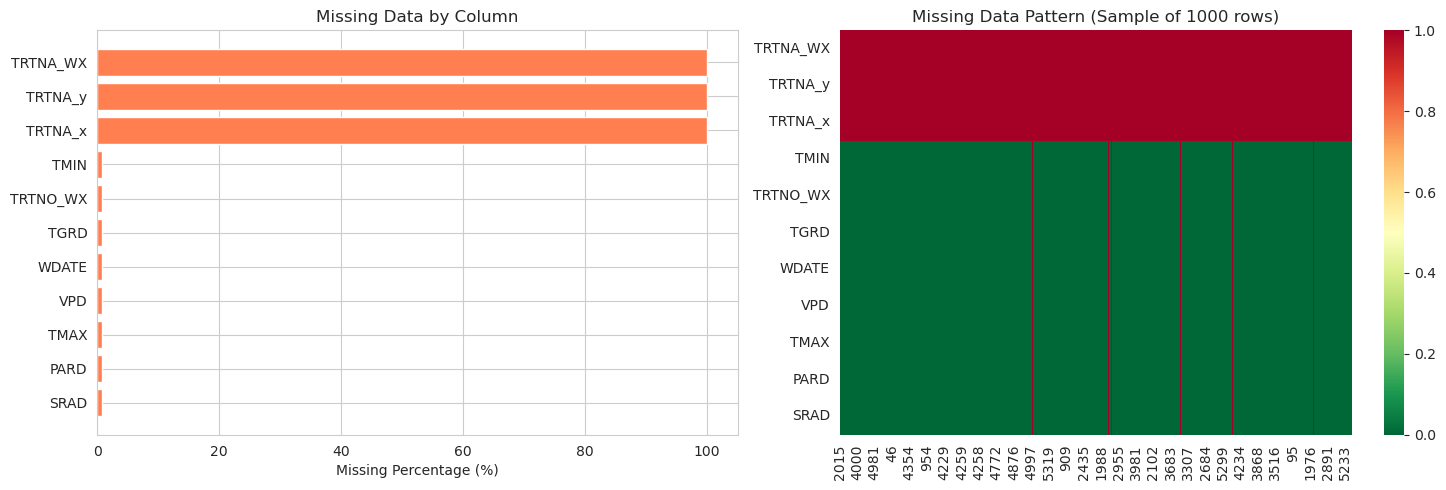


 Weather Data Missing Pattern:
  • Total rows affected: 40
  • Percentage: 0.72%
  • Affected RUNNO: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
  • Affected DAP range: 0 - 0


In [4]:
# 3. MISSING VALUE ANALYSIS

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage': (df.isna().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print("\n--- Missing Values Summary ---")
display(missing_summary[missing_summary['Missing_Count'] > 0])

if missing_summary['Missing_Count'].sum() == 0:
    print(" No missing values found!")

# Visualize missing data if any
if missing_summary['Missing_Count'].sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot
    missing_cols = missing_summary[missing_summary['Missing_Count'] > 0]
    axes[0].barh(missing_cols['Column'], missing_cols['Missing_Percentage'], color='coral')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Missing Data by Column')
    axes[0].invert_yaxis()

    # Heatmap of missing patterns
    missing_mask = df[missing_cols['Column']].isna()
    if len(missing_mask) > 0:
        sample_size = min(1000, len(missing_mask))
        sns.heatmap(missing_mask.sample(sample_size).T, cbar=True,
                   yticklabels=True, cmap='RdYlGn_r', ax=axes[1])
        axes[1].set_title(f'Missing Data Pattern (Sample of {sample_size} rows)')

    plt.tight_layout()
    plt.show()

# Investigate weather data missing pattern
weather_cols = ['SRAD', 'PARD', 'TMAX', 'TMIN', 'VPD', 'WDATE', 'TGRD', 'TRTNO_WX']
existing_weather_cols = [col for col in weather_cols if col in df.columns]

if existing_weather_cols:
    weather_missing = df[df[existing_weather_cols].isnull().any(axis=1)]

    if len(weather_missing) > 0:
        print(f"\n Weather Data Missing Pattern:")
        print(f"  • Total rows affected: {len(weather_missing)}")
        print(f"  • Percentage: {len(weather_missing)/len(df)*100:.2f}%")
        if 'RUNNO' in df.columns:
            print(f"  • Affected RUNNO: {sorted(weather_missing['RUNNO'].unique())}")
        if 'DAP' in df.columns:
            print(f"  • Affected DAP range: {weather_missing['DAP'].min()} - {weather_missing['DAP'].max()}")

In [5]:
# 4. DUPLICATE ANALYSIS

# 4A. EXACT DUPLICATE ROWS

duplicates = df.duplicated().sum()
print(f"\n Total exact duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"   Percentage: {(duplicates/len(df))*100:.2f}%")
    print("\n--- Sample Duplicate Rows ---")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No exact duplicate rows found!")

# Check for duplicates on key columns
if 'RUNNO' in df.columns and 'DAP' in df.columns:
    key_dup = df.duplicated(subset=['RUNNO', 'DAP']).sum()
    print(f"\n Duplicates on [RUNNO, DAP]: {key_dup}")

    if key_dup > 0:
        print(" Warning: Same run measured multiple times on same day!")
        print("\n--- Sample Key Column Duplicates ---")
        display(df[df.duplicated(subset=['RUNNO', 'DAP'], keep=False)].sort_values(['RUNNO', 'DAP']).head(10))
    else:
        print("No duplicates on key columns [RUNNO, DAP]")

# 4B. EXACT DUPLICATE COLUMNS

def find_exact_duplicate_columns(dataframe):
    """
    Find columns that have exactly identical values (including NaN positions).
    Returns dictionary of duplicate groups.
    """
    duplicate_groups = {}
    cols = dataframe.columns.tolist()
    checked = set()

    for i, col1 in enumerate(cols):
        if col1 in checked:
            continue

        duplicates_found = [col1]

        for col2 in cols[i+1:]:
            if col2 in checked:
                continue

            # Check exact equality (handles NaN properly)
            if dataframe[col1].equals(dataframe[col2]):
                duplicates_found.append(col2)
                checked.add(col2)

        if len(duplicates_found) > 1:
            duplicate_groups[tuple(duplicates_found)] = len(duplicates_found)

        checked.add(col1)

    return duplicate_groups

# Find exact duplicate columns

duplicate_cols = find_exact_duplicate_columns(df)

if duplicate_cols:
    print(f"\n Found {len(duplicate_cols)} group(s) of exact duplicate columns:\n")

    total_duplicates = 0
    columns_to_drop = []

    for idx, (cols, count) in enumerate(duplicate_cols.items(), 1):
        print(f"Group {idx}: {list(cols)}")
        print(f"Number of identical columns: {count}")
        print(f"Recommendation: Keep '{cols[0]}', drop the rest")

        # Show sample values to verify
        print(f"Sample values: {df[cols[0]].dropna().head(3).tolist()}")
        print()

        # Track columns to drop (keep first, drop rest)
        columns_to_drop.extend(list(cols[1:]))
        total_duplicates += (count - 1)

    print(f"Summary:")
    print(f"Total duplicate column groups: {len(duplicate_cols)}")
    print(f"Total columns that can be dropped: {total_duplicates}")
    print(f"\n Columns to drop: {columns_to_drop}")

    # Create summary table
    dup_summary = []
    for cols in duplicate_cols.keys():
        dup_summary.append({
            'Keep': cols[0],
            'Drop': ', '.join(cols[1:]),
            'Num_Duplicates': len(cols)
        })

    print("\n--- Duplicate Columns Summary Table ---")
    dup_df = pd.DataFrame(dup_summary)
    display(dup_df)

else:
    print("No exact duplicate columns found!")
    print("All 46 columns contain unique data.")


 Total exact duplicate rows: 0
No exact duplicate rows found!

 Duplicates on [RUNNO, DAP]: 0
No duplicates on key columns [RUNNO, DAP]

 Found 3 group(s) of exact duplicate columns:

Group 1: ['TRTNO', 'TRTNO_x', 'TRTNO_y']
Number of identical columns: 3
Recommendation: Keep 'TRTNO', drop the rest
Sample values: [1, 1, 1]

Group 2: ['LAID', 'LAI']
Number of identical columns: 2
Recommendation: Keep 'LAID', drop the rest
Sample values: [0.0, 0.0, 0.0]

Group 3: ['TRTNA_x', 'TRTNA_y', 'TRTNA_WX']
Number of identical columns: 3
Recommendation: Keep 'TRTNA_x', drop the rest
Sample values: []

Summary:
Total duplicate column groups: 3
Total columns that can be dropped: 5

 Columns to drop: ['TRTNO_x', 'TRTNO_y', 'LAI', 'TRTNA_y', 'TRTNA_WX']

--- Duplicate Columns Summary Table ---


,Keep,Drop,Num_Duplicates
0,TRTNO,"TRTNO_x, TRTNO_y",3
1,LAID,LAI,2
2,TRTNA_x,"TRTNA_y, TRTNA_WX",3



--- Growth Stage Transition Matrix ---

Transition counts (rows=current stage, columns=next stage):


GSTD_next,0.0,1.0,3.0,5.0,7.0,8.0
GSTD,,,,,,
0,1655,40,0,0,0,0
1,0,208,40,0,0,0
3,0,0,153,40,0,0
5,0,0,0,1332,40,0
7,0,0,0,0,560,40
8,0,0,0,0,0,1372



Transition probabilities (%):


GSTD_next,0.0,1.0,3.0,5.0,7.0,8.0
GSTD,,,,,,
0,97.64,2.36,0.00,0.00,0.00,0.00
1,0.00,83.87,16.13,0.00,0.00,0.00
3,0.00,0.00,79.27,20.73,0.00,0.00
5,0.00,0.00,0.00,97.08,2.92,0.00
7,0.00,0.00,0.00,0.00,93.33,6.67
8,0.00,0.00,0.00,0.00,0.00,100.00


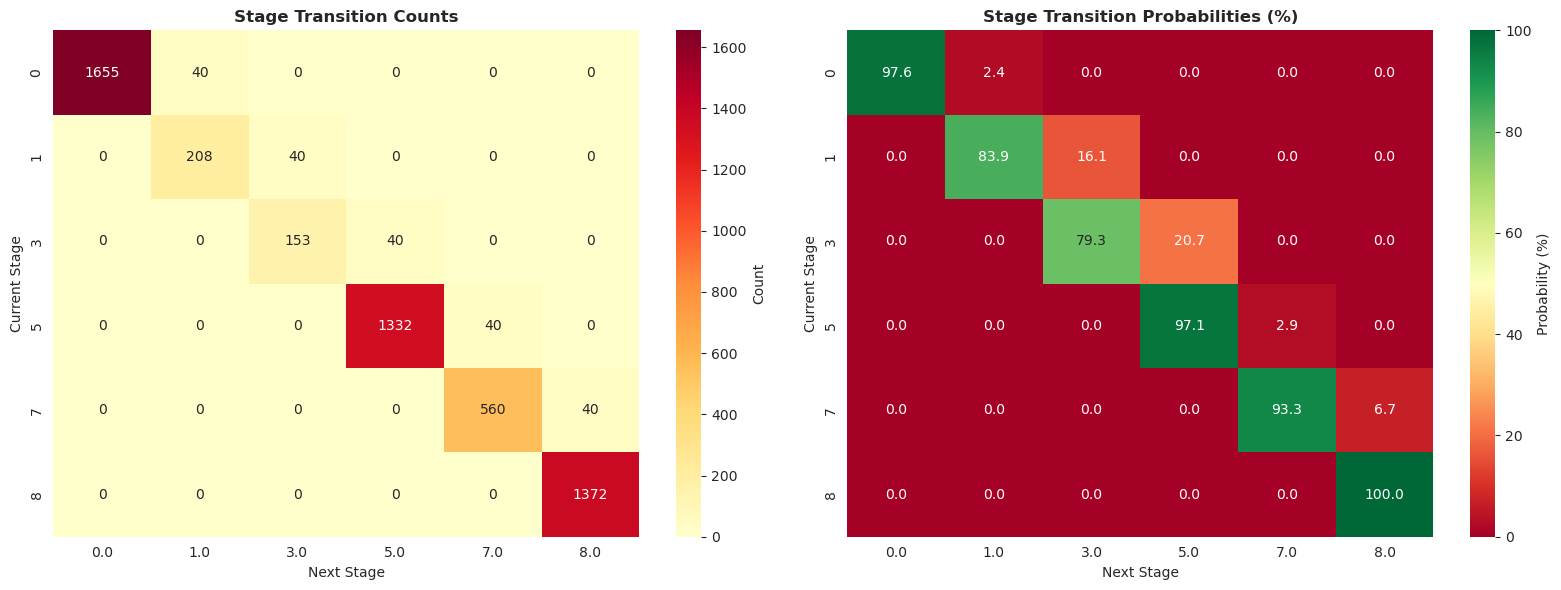


 Unusual Transition Patterns:
No stage reversals detected
Found 120 instances of plants skipping stages
Max jump: 2 stages

--- Days Spent in Each Growth Stage ---


,Occurrences,Mean_Days,Median_Days,Std_Days,Min_Days,Max_Days
GSTD,,,,,,
0,40,42.38,43.0,1.86,39,44
1,40,6.20,6.0,0.41,6,7
3,40,4.82,5.0,0.38,4,5
5,40,34.30,34.0,1.84,31,37
7,40,15.00,15.0,0.00,15,15
8,40,35.30,34.0,3.45,31,42


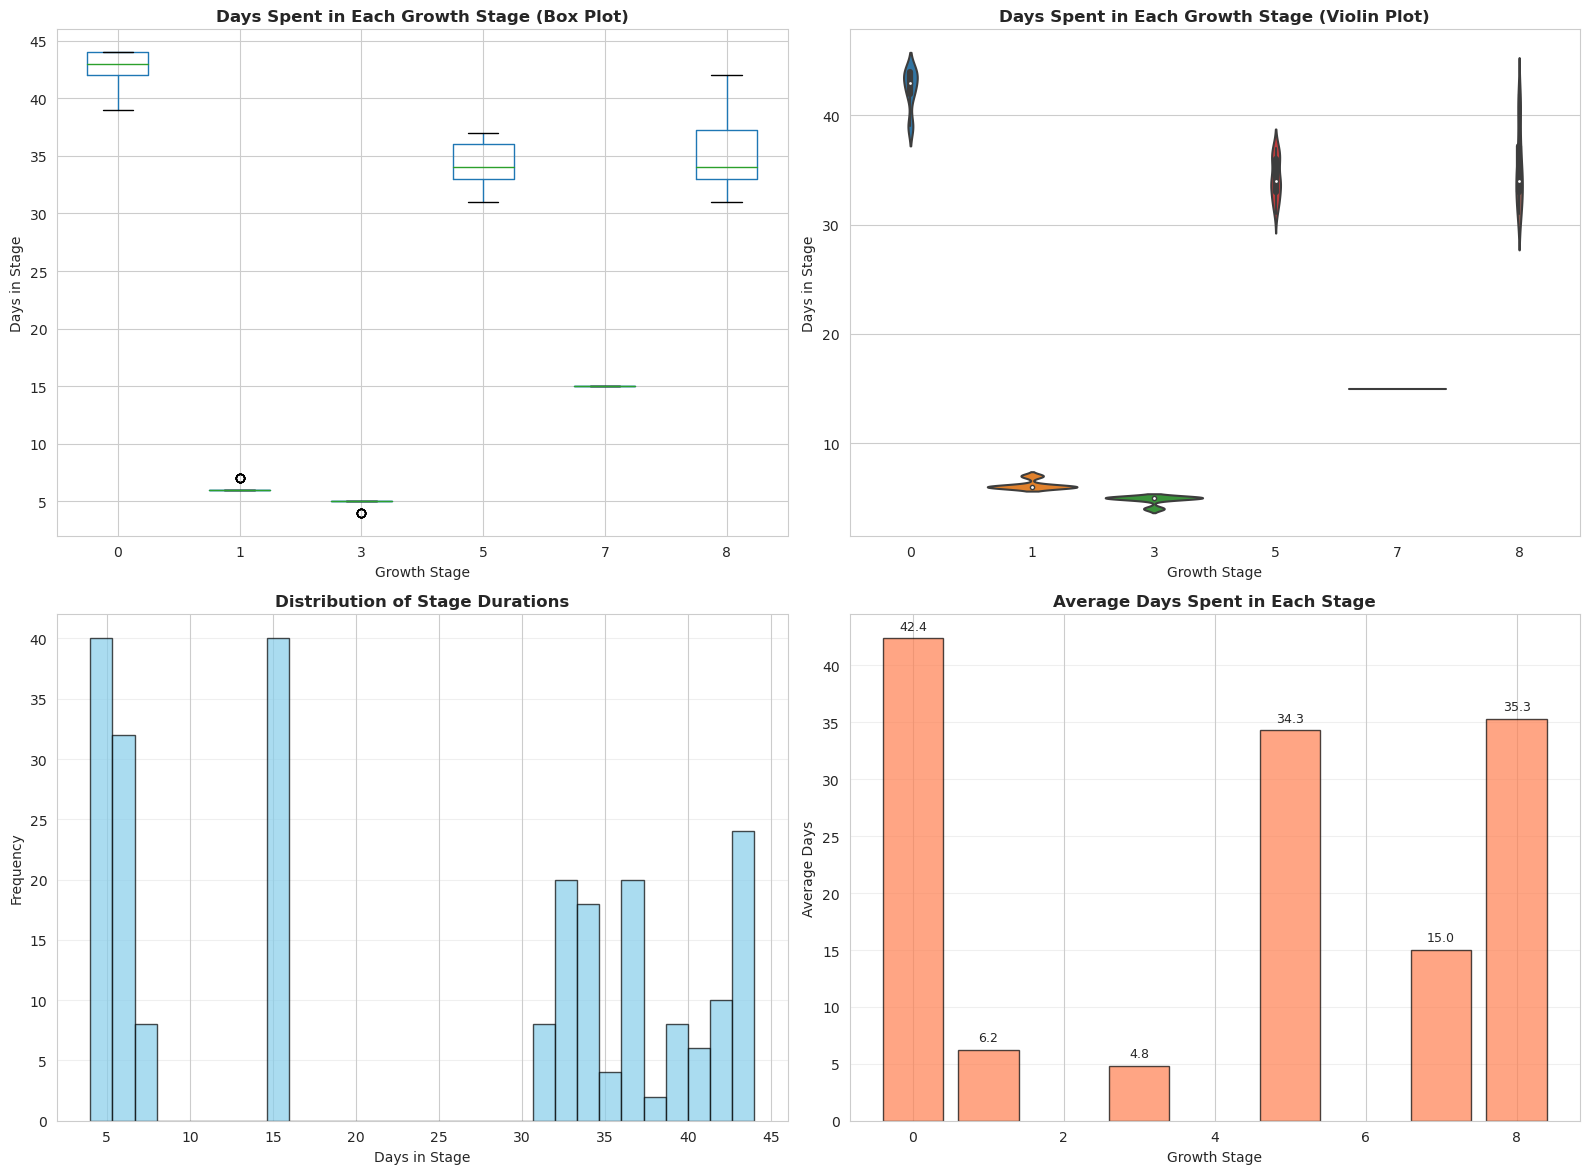


 Stage Duration Insights:
Fastest stage: 3 (4.8 days)
Slowest stage: 0 (42.4 days)

--- DAP When Each Stage is Reached ---


,Count,Mean_DAP,Median_DAP,Std_DAP,Min_DAP,Max_DAP
GSTD,,,,,,
0,40,0.00,0.0,0.00,0,0
1,40,42.38,43.0,1.86,39,44
3,40,48.58,49.0,2.06,45,51
5,40,53.40,54.0,1.88,50,55
7,40,87.70,89.0,3.45,81,92
8,40,102.70,104.0,3.45,96,107


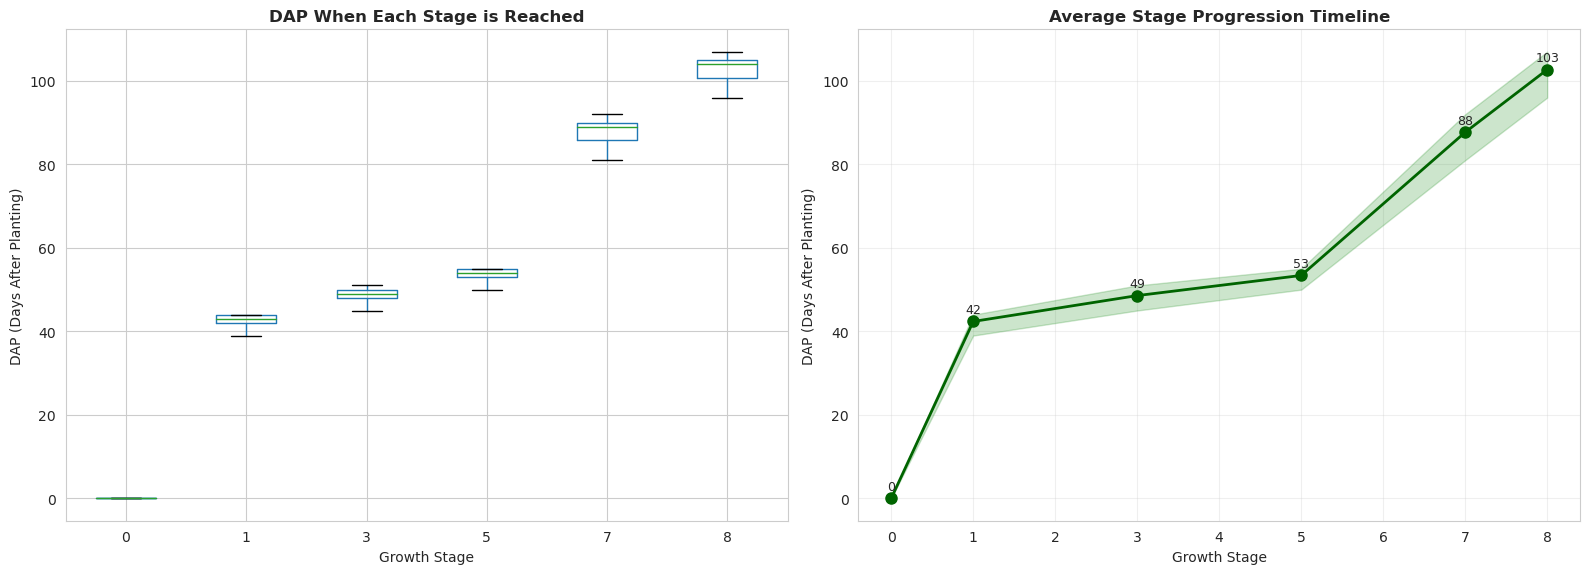

2.4 TREATMENT EFFECTS ON STAGE PROGRESSION

--- Average DAP at Each Stage by Treatment ---


GSTD,0,1,3,5,7,8
TRTNO,,,,,,
1,0.0,42.4,48.6,53.4,88.0,103.0
2,0.0,42.4,48.6,53.4,88.2,103.2
3,0.0,42.4,48.6,53.4,86.8,101.8
4,0.0,42.4,48.6,53.4,86.8,101.8
5,0.0,42.4,48.6,53.4,88.0,103.0
6,0.0,42.4,48.6,53.4,88.2,103.2
7,0.0,42.2,48.4,53.4,87.8,102.8
8,0.0,42.4,48.6,53.4,87.8,102.8


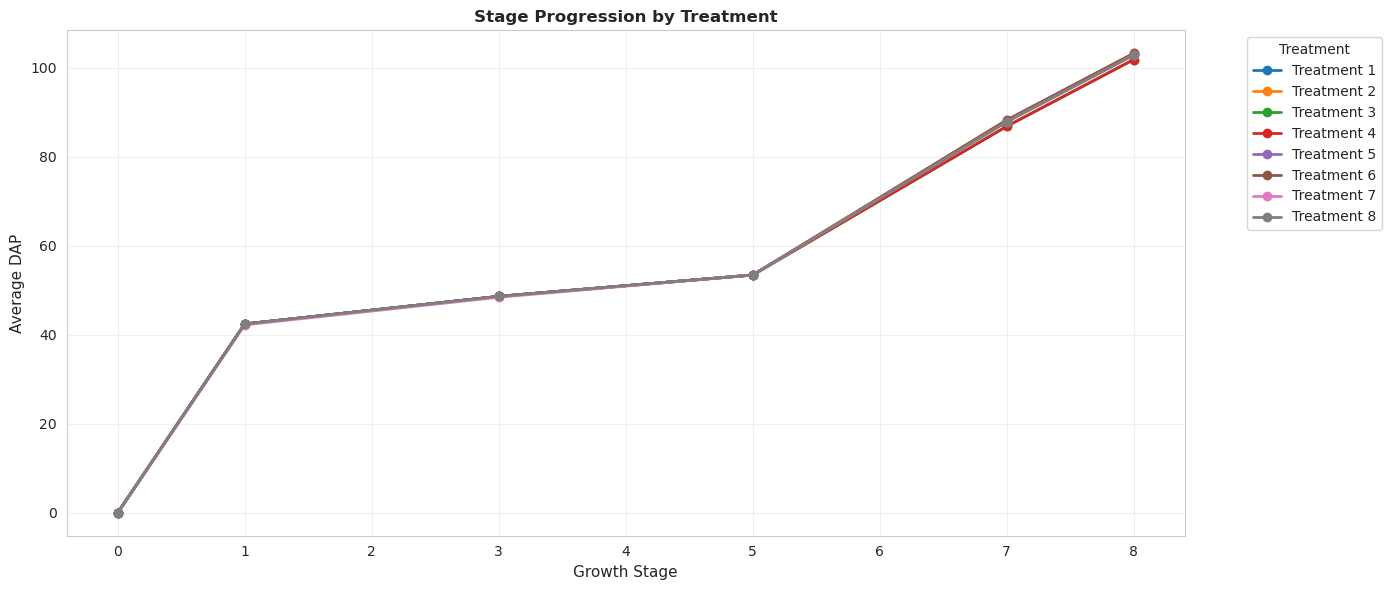


 Treatment Performance:
Fastest to final stage: Treatment 3
Slowest to final stage: Treatment 2

--- Percentage of Runs Reaching Each Stage ---


,Stage,Pct_Reached,Runs_Reached,Total_Runs
0,0,100.0,40,40
1,1,100.0,40,40
2,3,100.0,40,40
3,5,100.0,40,40
4,7,100.0,40,40
5,8,100.0,40,40


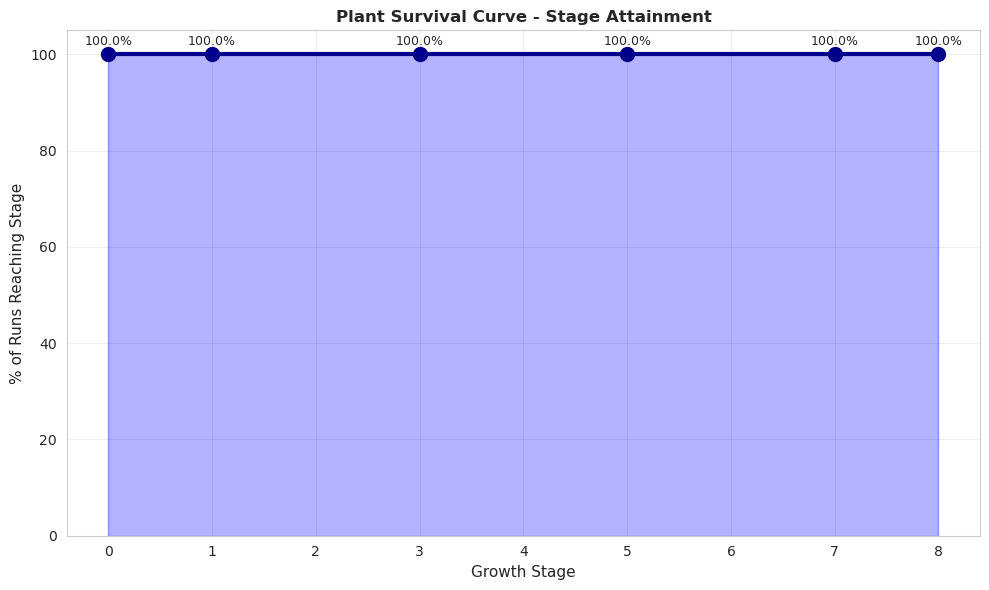


 All runs complete the full growth cycle


In [6]:
# SECTION 2: TARGET VARIABLE DEEP DIVE - STAGE TRANSITIONS

if 'GSTD' not in df.columns or 'DAP' not in df.columns or 'RUNNO' not in df.columns:
    print(" Required columns (GSTD, DAP, RUNNO) not found. Skipping this section.")
else:

    # 2.1 STAGE TRANSITION ANALYSIS

    print("\n--- Growth Stage Transition Matrix ---")

    # Calculate transitions for each run
    df_sorted = df.sort_values(['RUNNO', 'DAP'])
    df_sorted['GSTD_next'] = df_sorted.groupby('RUNNO')['GSTD'].shift(-1)

    # Create transition matrix (current stage -> next stage)
    transition_matrix = pd.crosstab(
        df_sorted['GSTD'],
        df_sorted['GSTD_next'],
        dropna=False
    )

    print("\nTransition counts (rows=current stage, columns=next stage):")
    display(transition_matrix)

    # Calculate transition probabilities
    transition_prob = transition_matrix.div(transition_matrix.sum(axis=1), axis=0) * 100
    print("\nTransition probabilities (%):")
    display(transition_prob.round(2))

    # Visualize transition matrix
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap of transition counts
    sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='YlOrRd',
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title('Stage Transition Counts', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Next Stage')
    axes[0].set_ylabel('Current Stage')

    # Heatmap of transition probabilities
    sns.heatmap(transition_prob, annot=True, fmt='.1f', cmap='RdYlGn',
                ax=axes[1], cbar_kws={'label': 'Probability (%)'})
    axes[1].set_title('Stage Transition Probabilities (%)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Next Stage')
    axes[1].set_ylabel('Current Stage')

    plt.tight_layout()
    plt.show()

    # Identify unusual transitions
    print("\n Unusual Transition Patterns:")

    # Check for stage reversals (going backwards)
    reversals = df_sorted[df_sorted['GSTD_next'] < df_sorted['GSTD']].dropna(subset=['GSTD_next'])
    if len(reversals) > 0:
        print(f"Found {len(reversals)} stage reversals (plants going backwards in growth)")
        print(f"Affected runs: {reversals['RUNNO'].unique()}")
    else:
        print("No stage reversals detected")

    # Check for stage skipping (jumping multiple stages)
    stage_jumps = df_sorted[df_sorted['GSTD_next'] - df_sorted['GSTD'] > 1].dropna(subset=['GSTD_next'])
    if len(stage_jumps) > 0:
        print(f"Found {len(stage_jumps)} instances of plants skipping stages")
        print(f"Max jump: {int((stage_jumps['GSTD_next'] - stage_jumps['GSTD']).max())} stages")
    else:
        print("No stage skipping detected")

    # 2.2 TIME TO TRANSITION - DAYS SPENT IN EACH STAGE

    # Calculate days spent in each stage for each run
    stage_duration = []

    for run in df['RUNNO'].unique():
        run_data = df[df['RUNNO'] == run].sort_values('DAP')

        # Find stage changes
        run_data['stage_changed'] = run_data['GSTD'].diff() != 0
        run_data['stage_group'] = run_data['stage_changed'].cumsum()

        # Calculate duration for each stage period
        for group_id, group in run_data.groupby('stage_group'):
            stage_duration.append({
                'RUNNO': run,
                'GSTD': group['GSTD'].iloc[0],
                'Start_DAP': group['DAP'].min(),
                'End_DAP': group['DAP'].max(),
                'Days_in_Stage': group['DAP'].max() - group['DAP'].min() + 1,
                'TRTNO': group['TRTNO'].iloc[0] if 'TRTNO' in df.columns else None
            })

    duration_df = pd.DataFrame(stage_duration)

    print("\n--- Days Spent in Each Growth Stage ---")
    stage_summary = duration_df.groupby('GSTD')['Days_in_Stage'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    stage_summary.columns = ['Occurrences', 'Mean_Days', 'Median_Days', 'Std_Days', 'Min_Days', 'Max_Days']
    display(stage_summary)

    # Visualize stage durations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Box plot of days in each stage
    duration_df.boxplot(column='Days_in_Stage', by='GSTD', ax=axes[0, 0])
    axes[0, 0].set_title('Days Spent in Each Growth Stage (Box Plot)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Growth Stage')
    axes[0, 0].set_ylabel('Days in Stage')
    axes[0, 0].get_figure().suptitle('')  # Remove default title

    # Violin plot for better distribution view
    sns.violinplot(data=duration_df, x='GSTD', y='Days_in_Stage', ax=axes[0, 1])
    axes[0, 1].set_title('Days Spent in Each Growth Stage (Violin Plot)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Growth Stage')
    axes[0, 1].set_ylabel('Days in Stage')

    # Histogram of all stage durations
    axes[1, 0].hist(duration_df['Days_in_Stage'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Days in Stage')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Stage Durations', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Average days in each stage (bar chart)
    stage_means = duration_df.groupby('GSTD')['Days_in_Stage'].mean()
    axes[1, 1].bar(stage_means.index, stage_means.values, color='coral', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Growth Stage')
    axes[1, 1].set_ylabel('Average Days')
    axes[1, 1].set_title('Average Days Spent in Each Stage', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(stage_means.values):
        axes[1, 1].text(stage_means.index[i], v + 0.5, f'{v:.1f}',
                       ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Identify stages with high variability
    print("\n Stage Duration Insights:")
    high_var_stages = stage_summary[stage_summary['Std_Days'] > stage_summary['Mean_Days'] * 0.5]
    if len(high_var_stages) > 0:
        print(f"High variability stages (std > 50% of mean):")
        for stage in high_var_stages.index:
            print(f"Stage {stage}: {stage_summary.loc[stage, 'Mean_Days']:.1f} ± {stage_summary.loc[stage, 'Std_Days']:.1f} days")

    fastest_stage = stage_summary['Mean_Days'].idxmin()
    slowest_stage = stage_summary['Mean_Days'].idxmax()
    print(f"Fastest stage: {fastest_stage} ({stage_summary.loc[fastest_stage, 'Mean_Days']:.1f} days)")
    print(f"Slowest stage: {slowest_stage} ({stage_summary.loc[slowest_stage, 'Mean_Days']:.1f} days)")

    # 2.3 DAP AT EACH STAGE TRANSITION

    # Find the DAP when each stage is first reached for each run
    stage_entry = df.sort_values(['RUNNO', 'DAP']).groupby(['RUNNO', 'GSTD'])['DAP'].min().reset_index()
    stage_entry.columns = ['RUNNO', 'GSTD', 'Entry_DAP']

    print("\n--- DAP When Each Stage is Reached ---")
    dap_summary = stage_entry.groupby('GSTD')['Entry_DAP'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    dap_summary.columns = ['Count', 'Mean_DAP', 'Median_DAP', 'Std_DAP', 'Min_DAP', 'Max_DAP']
    display(dap_summary)

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Box plot of DAP at each stage entry
    stage_entry.boxplot(column='Entry_DAP', by='GSTD', ax=axes[0])
    axes[0].set_title('DAP When Each Stage is Reached', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Growth Stage')
    axes[0].set_ylabel('DAP (Days After Planting)')
    axes[0].get_figure().suptitle('')

    # Line plot showing progression
    stage_means_dap = stage_entry.groupby('GSTD')['Entry_DAP'].mean()
    axes[1].plot(stage_means_dap.index, stage_means_dap.values,
                marker='o', linewidth=2, markersize=8, color='darkgreen')
    axes[1].fill_between(stage_means_dap.index,
                         stage_entry.groupby('GSTD')['Entry_DAP'].min(),
                         stage_entry.groupby('GSTD')['Entry_DAP'].max(),
                         alpha=0.2, color='green')
    axes[1].set_xlabel('Growth Stage')
    axes[1].set_ylabel('DAP (Days After Planting)')
    axes[1].set_title('Average Stage Progression Timeline', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Add labels
    for stage, dap in stage_means_dap.items():
        axes[1].text(stage, dap + 2, f'{dap:.0f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 2.4 TREATMENT EFFECTS ON STAGE PROGRESSION

    if 'TRTNO' in df.columns:
        print("2.4 TREATMENT EFFECTS ON STAGE PROGRESSION")

        # Compare stage progression across treatments
        treatment_stage = stage_entry.merge(
            df[['RUNNO', 'TRTNO']].drop_duplicates(),
            on='RUNNO'
        )

        print("\n--- Average DAP at Each Stage by Treatment ---")
        treatment_comparison = treatment_stage.pivot_table(
            index='TRTNO',
            columns='GSTD',
            values='Entry_DAP',
            aggfunc='mean'
        ).round(1)
        display(treatment_comparison)

        # Visualize treatment effects
        fig, ax = plt.subplots(figsize=(14, 6))

        for trt in treatment_stage['TRTNO'].unique():
            trt_data = treatment_stage[treatment_stage['TRTNO'] == trt].groupby('GSTD')['Entry_DAP'].mean()
            ax.plot(trt_data.index, trt_data.values, marker='o', label=f'Treatment {trt}', linewidth=2)

        ax.set_xlabel('Growth Stage', fontsize=11)
        ax.set_ylabel('Average DAP', fontsize=11)
        ax.set_title('Stage Progression by Treatment', fontsize=12, fontweight='bold')
        ax.legend(title='Treatment', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Identify fastest/slowest treatments
        final_stage_dap = treatment_stage[treatment_stage['GSTD'] == treatment_stage['GSTD'].max()]
        fastest_treatment = final_stage_dap.groupby('TRTNO')['Entry_DAP'].mean().idxmin()
        slowest_treatment = final_stage_dap.groupby('TRTNO')['Entry_DAP'].mean().idxmax()

        print(f"\n Treatment Performance:")
        print(f"Fastest to final stage: Treatment {fastest_treatment}")
        print(f"Slowest to final stage: Treatment {slowest_treatment}")

    # 2.5 SURVIVAL-STYLE ANALYSIS

    # Calculate what % of runs reach each stage
    max_stage_per_run = df.groupby('RUNNO')['GSTD'].max()

    survival_data = []
    for stage in sorted(df['GSTD'].unique()):
        pct_reached = (max_stage_per_run >= stage).sum() / len(max_stage_per_run) * 100
        survival_data.append({
            'Stage': stage,
            'Pct_Reached': pct_reached,
            'Runs_Reached': (max_stage_per_run >= stage).sum(),
            'Total_Runs': len(max_stage_per_run)
        })

    survival_df = pd.DataFrame(survival_data)

    print("\n--- Percentage of Runs Reaching Each Stage ---")
    display(survival_df)

    # Visualize survival curve
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(survival_df['Stage'], survival_df['Pct_Reached'],
           marker='o', linewidth=3, markersize=10, color='darkblue')
    ax.fill_between(survival_df['Stage'], survival_df['Pct_Reached'],
                    alpha=0.3, color='blue')
    ax.set_xlabel('Growth Stage', fontsize=11)
    ax.set_ylabel('% of Runs Reaching Stage', fontsize=11)
    ax.set_title('Plant Survival Curve - Stage Attainment', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3)

    # Add percentage labels
    for idx, row in survival_df.iterrows():
        ax.text(row['Stage'], row['Pct_Reached'] + 2,
               f"{row['Pct_Reached']:.1f}%",
               ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Check if all runs complete all stages
    if survival_df['Pct_Reached'].min() < 100:
        incomplete_stage = survival_df[survival_df['Pct_Reached'] < 100].iloc[0]
        print(f"\n Not all runs complete the growth cycle:")
        print(f"First incomplete stage: {incomplete_stage['Stage']}")
        print(f"Only {incomplete_stage['Pct_Reached']:.1f}% of runs reach this stage")
    else:
        print("\n All runs complete the full growth cycle")


SECTION 3: CORRELATION ANALYSIS
3.1 CORRELATION WITH TARGET VARIABLE (GSTD)

--- Top 15 Features Correlated with GSTD ---


,Feature,Spearman_Corr,Pearson_Corr,Abs_Spearman
0,GSTD,1.000000,1.000000,1.000000
1,DOY,0.966521,0.953117,0.966521
2,DAP,0.966521,0.953117,0.966521
3,GWAD,0.894109,0.833616,0.894109
4,TGRD,0.838356,0.806943,0.838356
5,TMAX,0.812442,0.777399,0.812442
6,CWAD,0.807729,0.776203,0.807729
7,TMIN,0.805904,0.757176,0.805904
8,NI9D,0.625761,0.583522,0.625761
40,SW2D,-0.568725,-0.584170,0.568725


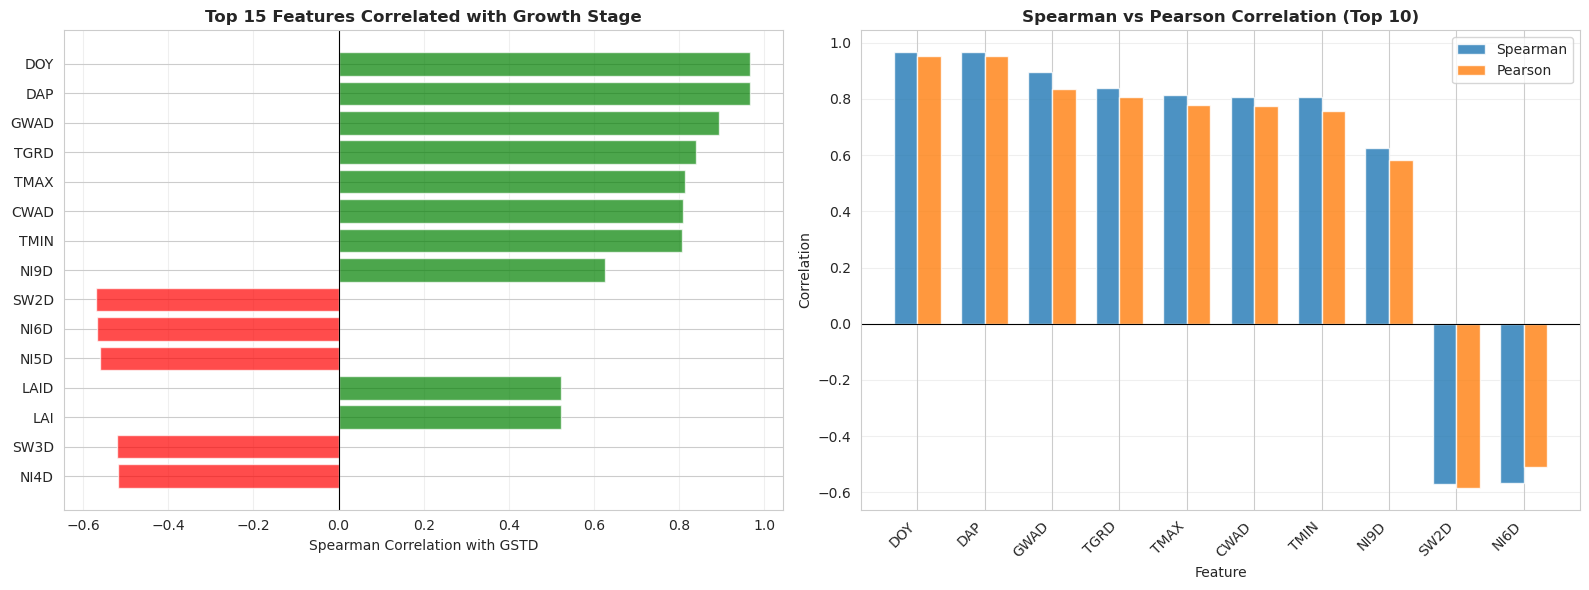


 Features with |correlation| > 0.5: 15

Strongly correlated features:
   • DOY: 0.967 (positive)
   • DAP: 0.967 (positive)
   • GWAD: 0.894 (positive)
   • TGRD: 0.838 (positive)
   • TMAX: 0.812 (positive)
   • CWAD: 0.808 (positive)
   • TMIN: 0.806 (positive)
   • NI9D: 0.626 (positive)
   • SW2D: -0.569 (negative)
   • NI6D: -0.568 (negative)
   • NI5D: -0.561 (negative)
   • LAID: 0.522 (positive)
   • LAI: 0.522 (positive)
   • SW3D: -0.520 (negative)
   • NI4D: -0.518 (negative)
3.2 OVERALL CORRELATION MATRIX

--- Correlation Matrix (15 key features) ---


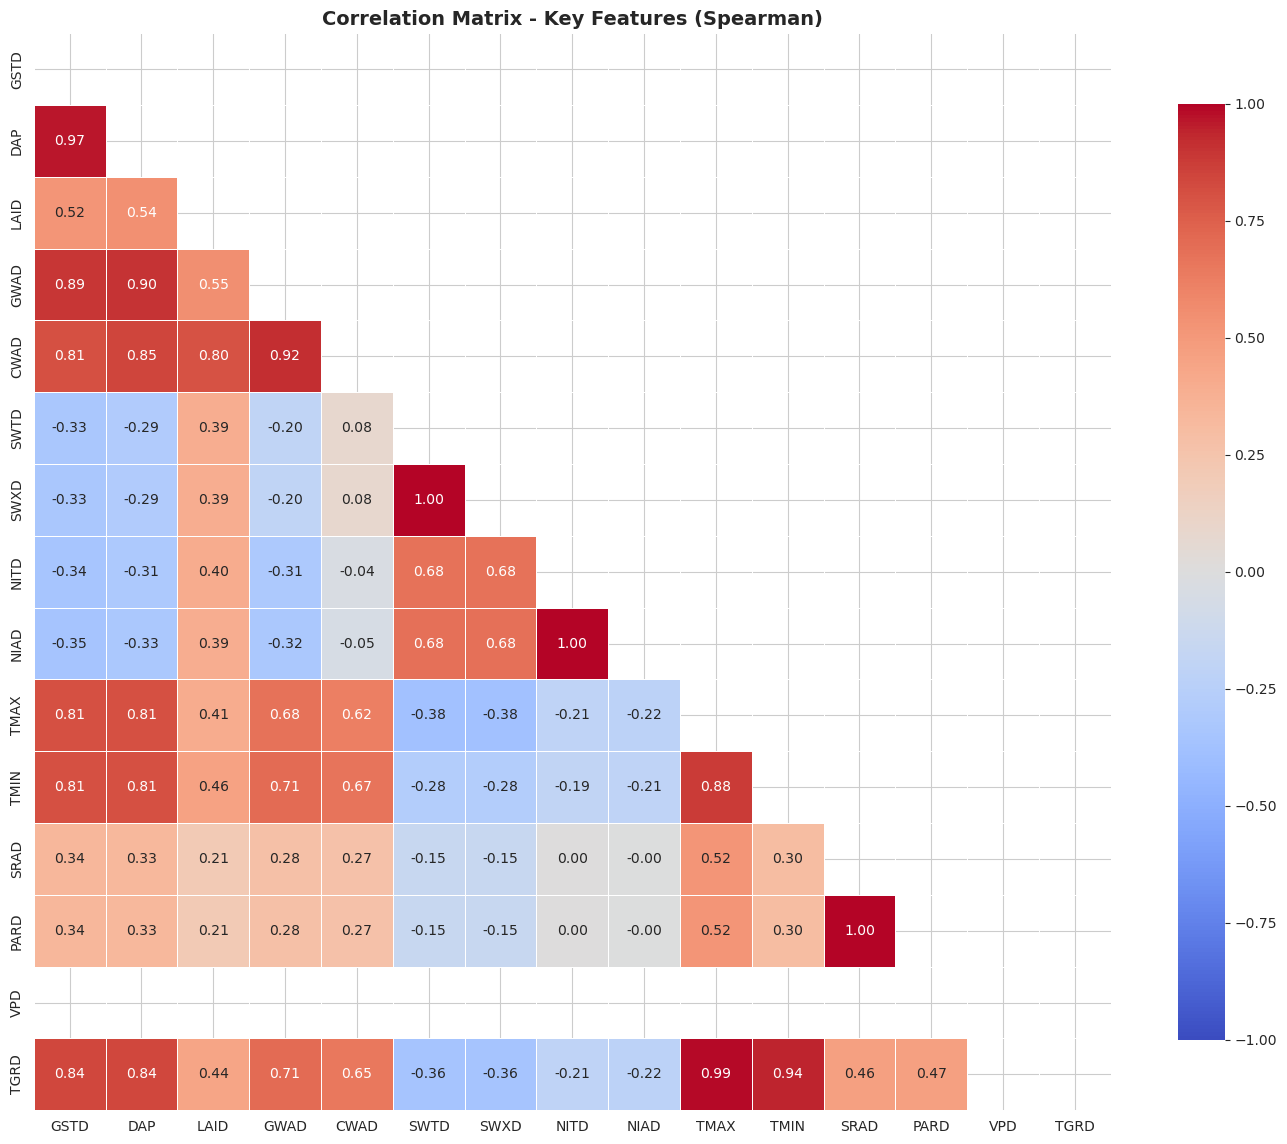


--- Highly Correlated Feature Pairs (|r| > 0.8) ---


,Feature_1,Feature_2,Correlation
17,SRAD,PARD,0.999944
12,SWTD,SWXD,0.999899
13,NITD,NIAD,0.997641
15,TMAX,TGRD,0.987363
0,GSTD,DAP,0.966521
16,TMIN,TGRD,0.939485
11,GWAD,CWAD,0.916167
6,DAP,GWAD,0.904604
1,GSTD,GWAD,0.894109
14,TMAX,TMIN,0.879549



 Found 18 highly correlated pairs - potential multicollinearity
3.3 SOIL LAYER CORRELATION PATTERNS

--- Soil Water Layers Correlation ---


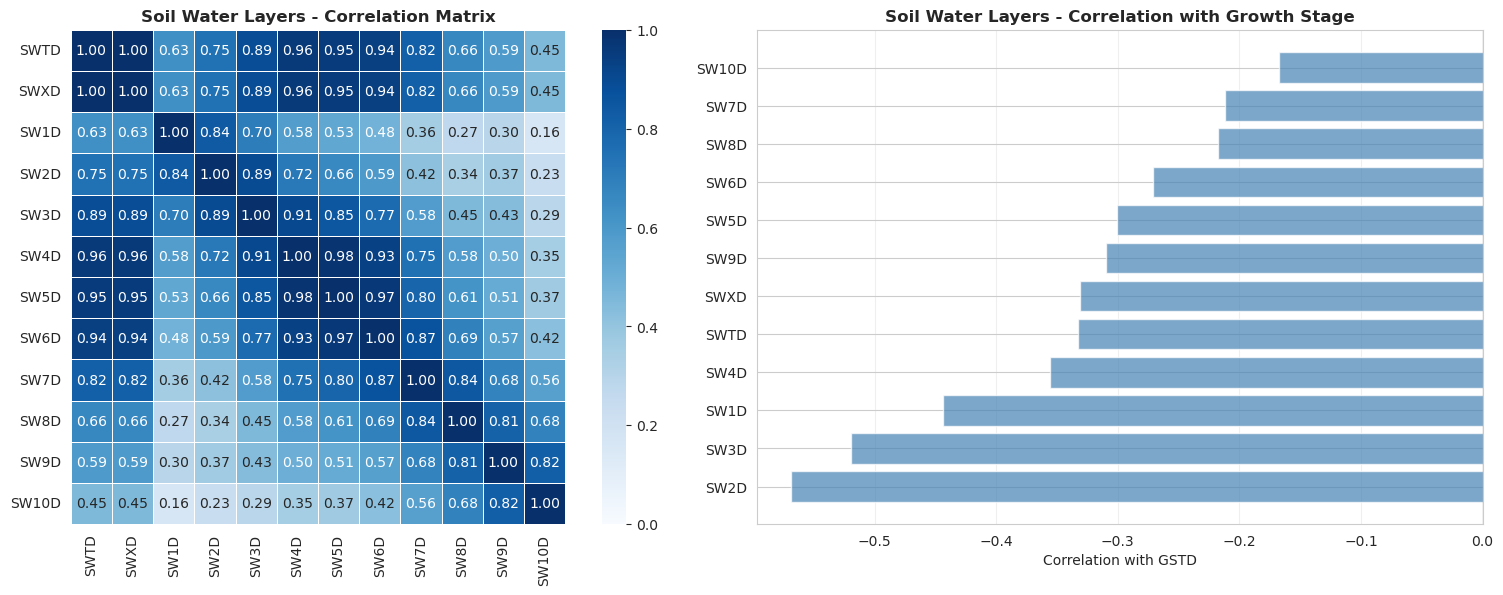


 Most important water layer: SW2D (r = -0.569)

--- Soil Nitrate Layers Correlation ---


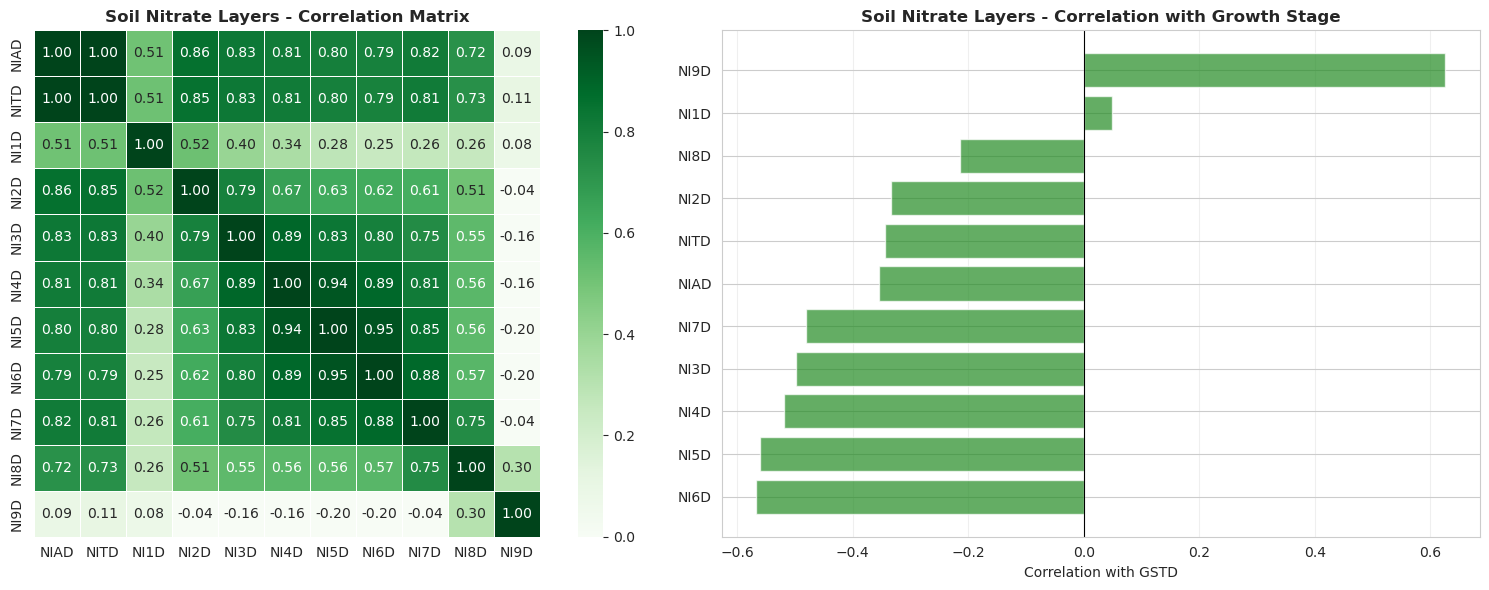


 Most important nitrate layer: NI9D (r = 0.626)
3.4 SCATTER PLOTS - KEY RELATIONSHIPS WITH GSTD


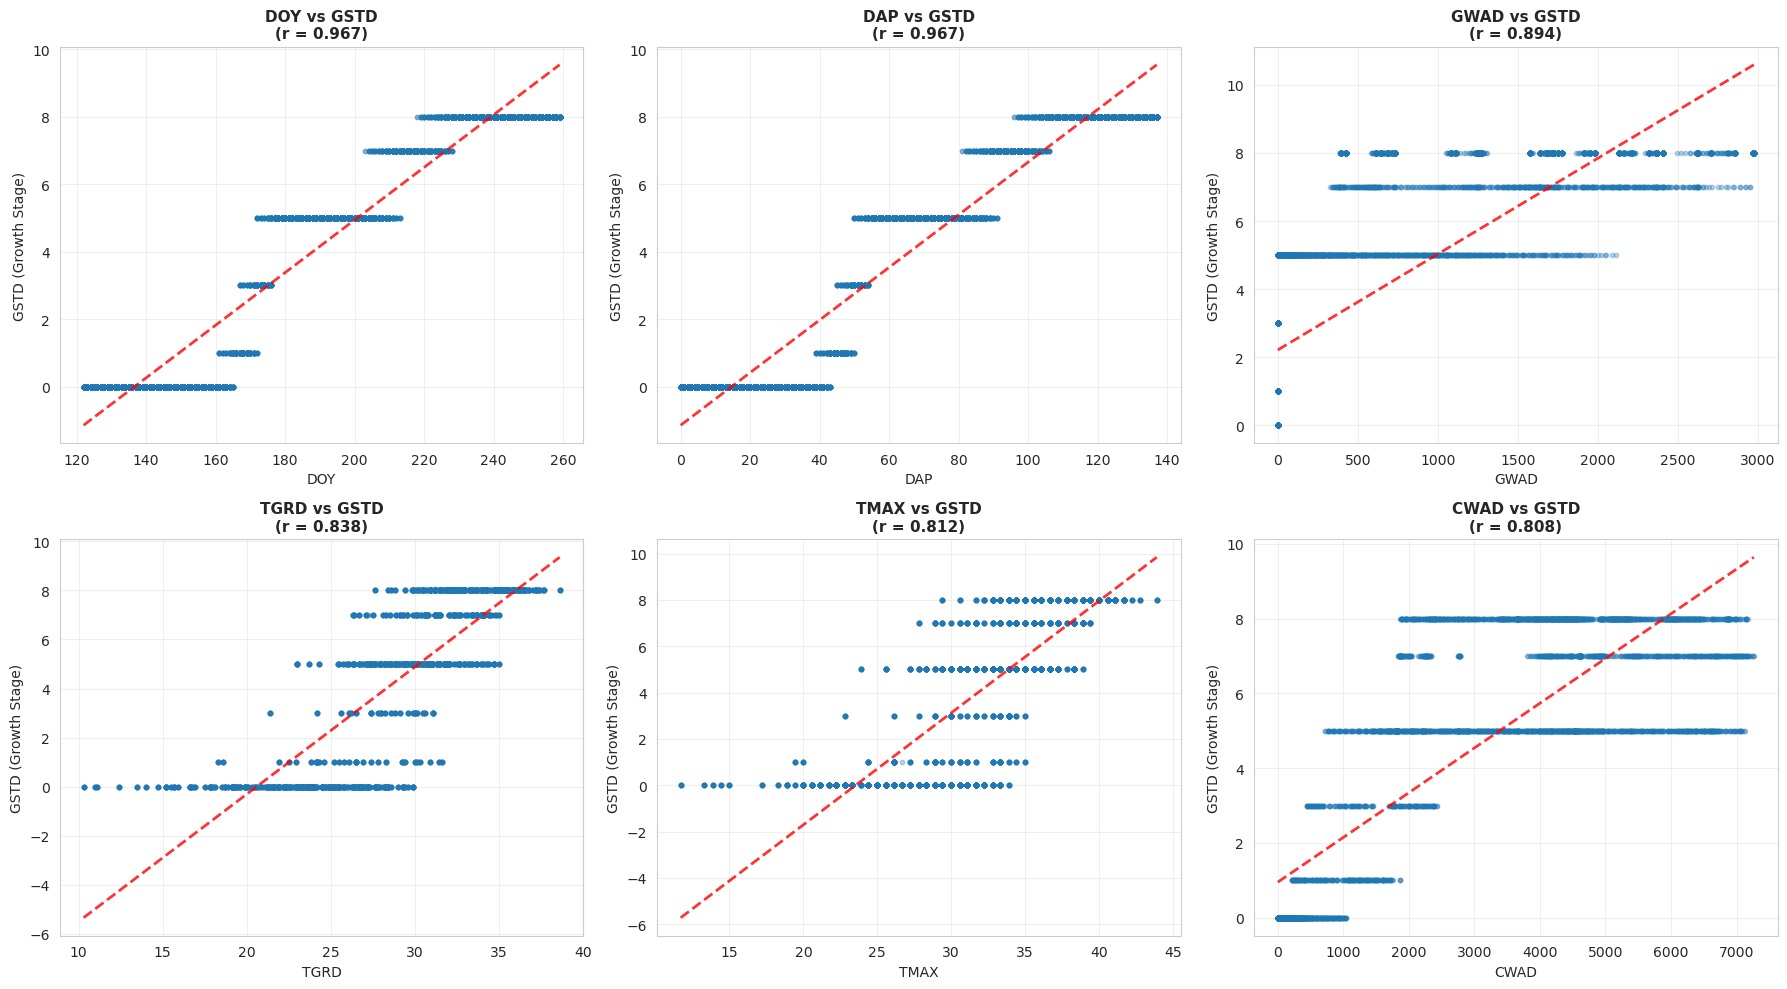

3.5 STAGE-SPECIFIC CORRELATIONS

--- How correlations change across growth stages ---


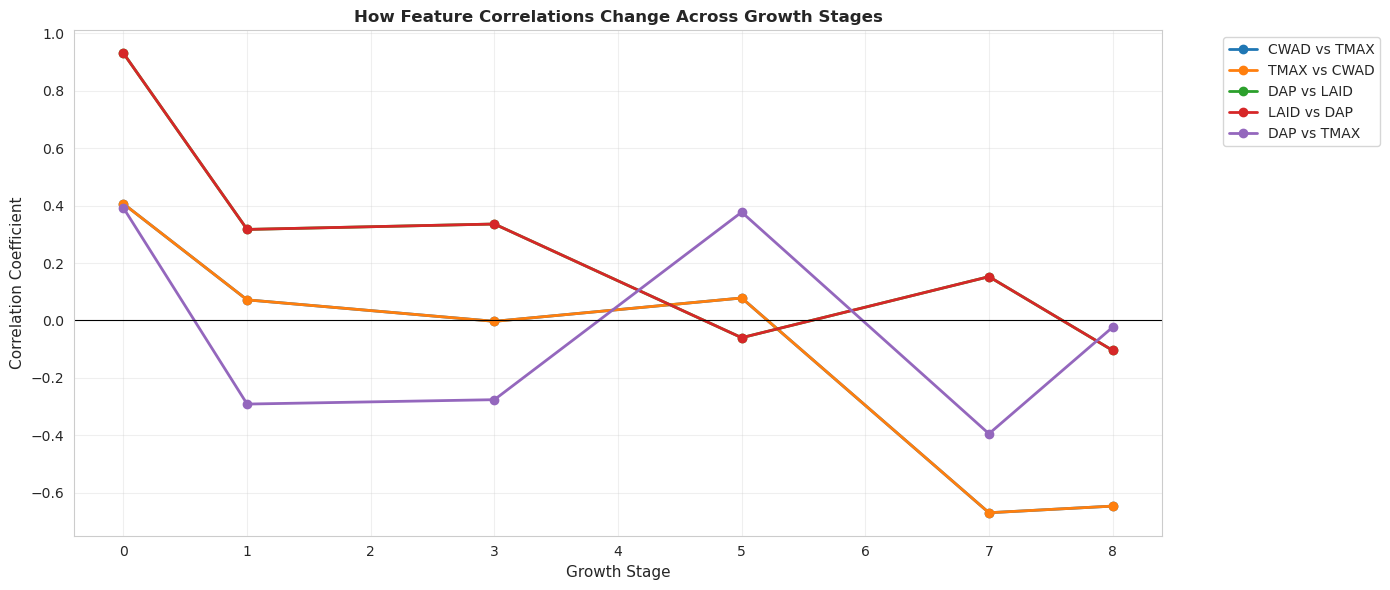


 Showing top 5 feature pairs with most variable correlations across stages


In [7]:
# SECTION 3: CORRELATION ANALYSIS

print("SECTION 3: CORRELATION ANALYSIS")

# 3.1 CORRELATION WITH TARGET (GSTD)

print("3.1 CORRELATION WITH TARGET VARIABLE (GSTD)")

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'GSTD' in numeric_cols:
    # Calculate Spearman correlation (better for ordinal target)
    spearman_corr = df[numeric_cols].corr(method='spearman')['GSTD'].sort_values(ascending=False)

    # Calculate Pearson correlation for comparison
    pearson_corr = df[numeric_cols].corr(method='pearson')['GSTD'].sort_values(ascending=False)

    # Combine into summary
    corr_summary = pd.DataFrame({
        'Feature': spearman_corr.index,
        'Spearman_Corr': spearman_corr.values,
        'Pearson_Corr': pearson_corr.values,
        'Abs_Spearman': abs(spearman_corr.values)
    }).sort_values('Abs_Spearman', ascending=False)

    print("\n--- Top 15 Features Correlated with GSTD ---")
    display(corr_summary.head(15))

    # Visualize top correlations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar plot of top positive and negative correlations
    top_n = 15
    top_corr = corr_summary[corr_summary['Feature'] != 'GSTD'].head(top_n)

    colors = ['green' if x > 0 else 'red' for x in top_corr['Spearman_Corr']]
    axes[0].barh(range(len(top_corr)), top_corr['Spearman_Corr'], color=colors, alpha=0.7)
    axes[0].set_yticks(range(len(top_corr)))
    axes[0].set_yticklabels(top_corr['Feature'])
    axes[0].set_xlabel('Spearman Correlation with GSTD')
    axes[0].set_title(f'Top {top_n} Features Correlated with Growth Stage', fontsize=12, fontweight='bold')
    axes[0].axvline(x=0, color='black', linewidth=0.8)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()

    # Spearman vs Pearson comparison for top features
    top_10 = corr_summary[corr_summary['Feature'] != 'GSTD'].head(10)
    x = np.arange(len(top_10))
    width = 0.35

    axes[1].bar(x - width/2, top_10['Spearman_Corr'], width, label='Spearman', alpha=0.8)
    axes[1].bar(x + width/2, top_10['Pearson_Corr'], width, label='Pearson', alpha=0.8)
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Correlation')
    axes[1].set_title('Spearman vs Pearson Correlation (Top 10)', fontsize=12, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top_10['Feature'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].axhline(y=0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    # Identify strong correlations
    strong_corr = corr_summary[(corr_summary['Abs_Spearman'] > 0.5) & (corr_summary['Feature'] != 'GSTD')]
    print(f"\n Features with |correlation| > 0.5: {len(strong_corr)}")
    if len(strong_corr) > 0:
        print("\nStrongly correlated features:")
        for idx, row in strong_corr.iterrows():
            direction = "positive" if row['Spearman_Corr'] > 0 else "negative"
            print(f"   • {row['Feature']}: {row['Spearman_Corr']:.3f} ({direction})")

# 3.2 OVERALL CORRELATION MATRIX

print("3.2 OVERALL CORRELATION MATRIX")

# Focus on key features to avoid overcrowding
key_features = ['GSTD', 'DAP', 'LAID', 'GWAD', 'CWAD', 'SWTD', 'SWXD', 'NITD', 'NIAD',
                'TMAX', 'TMIN', 'SRAD', 'PARD', 'VPD', 'TGRD']
existing_key_features = [col for col in key_features if col in df.columns]

if len(existing_key_features) > 2:
    # Calculate correlation matrix
    corr_matrix = df[existing_key_features].corr(method='spearman')

    print(f"\n--- Correlation Matrix ({len(existing_key_features)} key features) ---")

    # Create heatmap
    fig, ax = plt.subplots(figsize=(14, 12))

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Plot heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True,
                linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=ax)

    ax.set_title('Correlation Matrix - Key Features (Spearman)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Find highly correlated feature pairs (excluding GSTD)
    print("\n--- Highly Correlated Feature Pairs (|r| > 0.8) ---")
    high_corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.8:
                high_corr_pairs.append({
                    'Feature_1': corr_matrix.columns[i],
                    'Feature_2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
        display(high_corr_df)
        print(f"\n Found {len(high_corr_pairs)} highly correlated pairs - potential multicollinearity")
    else:
        print("No highly correlated pairs found (threshold: 0.8)")

# 3.3 SOIL LAYER CORRELATIONS

print("3.3 SOIL LAYER CORRELATION PATTERNS")


# Water content layers
water_layers = [col for col in df.columns if col.startswith('SW') and col.endswith('D') and len(col) <= 5]
# Nitrate layers
nitrate_layers = [col for col in df.columns if col.startswith('NI') and col.endswith('D') and len(col) <= 5]

if water_layers and len(water_layers) > 2:
    print("\n--- Soil Water Layers Correlation ---")
    water_corr = df[water_layers].corr(method='spearman')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Soil water heatmap
    sns.heatmap(water_corr, annot=True, fmt='.2f', cmap='Blues',
                square=True, linewidths=0.5, ax=axes[0],
                vmin=0, vmax=1)
    axes[0].set_title('Soil Water Layers - Correlation Matrix', fontsize=12, fontweight='bold')

    # Correlation with GSTD
    if 'GSTD' in df.columns:
        water_gstd_corr = df[water_layers + ['GSTD']].corr(method='spearman')['GSTD'].drop('GSTD').sort_values(ascending=False)

        axes[1].barh(range(len(water_gstd_corr)), water_gstd_corr.values,
                    color='steelblue', alpha=0.7)
        axes[1].set_yticks(range(len(water_gstd_corr)))
        axes[1].set_yticklabels(water_gstd_corr.index)
        axes[1].set_xlabel('Correlation with GSTD')
        axes[1].set_title('Soil Water Layers - Correlation with Growth Stage', fontsize=12, fontweight='bold')
        axes[1].axvline(x=0, color='black', linewidth=0.8)
        axes[1].grid(axis='x', alpha=0.3)
        axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Identify which layers matter most
    if 'GSTD' in df.columns:
        most_important_water = water_gstd_corr.abs().idxmax()
        print(f"\n Most important water layer: {most_important_water} (r = {water_gstd_corr[most_important_water]:.3f})")

if nitrate_layers and len(nitrate_layers) > 2:
    print("\n--- Soil Nitrate Layers Correlation ---")
    nitrate_corr = df[nitrate_layers].corr(method='spearman')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Soil nitrate heatmap
    sns.heatmap(nitrate_corr, annot=True, fmt='.2f', cmap='Greens',
                square=True, linewidths=0.5, ax=axes[0],
                vmin=0, vmax=1)
    axes[0].set_title('Soil Nitrate Layers - Correlation Matrix', fontsize=12, fontweight='bold')

    # Correlation with GSTD
    if 'GSTD' in df.columns:
        nitrate_gstd_corr = df[nitrate_layers + ['GSTD']].corr(method='spearman')['GSTD'].drop('GSTD').sort_values(ascending=False)

        axes[1].barh(range(len(nitrate_gstd_corr)), nitrate_gstd_corr.values,
                    color='forestgreen', alpha=0.7)
        axes[1].set_yticks(range(len(nitrate_gstd_corr)))
        axes[1].set_yticklabels(nitrate_gstd_corr.index)
        axes[1].set_xlabel('Correlation with GSTD')
        axes[1].set_title('Soil Nitrate Layers - Correlation with Growth Stage', fontsize=12, fontweight='bold')
        axes[1].axvline(x=0, color='black', linewidth=0.8)
        axes[1].grid(axis='x', alpha=0.3)
        axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    # Identify which layers matter most
    if 'GSTD' in df.columns:
        most_important_nitrate = nitrate_gstd_corr.abs().idxmax()
        print(f"\n Most important nitrate layer: {most_important_nitrate} (r = {nitrate_gstd_corr[most_important_nitrate]:.3f})")

# 3.4 SCATTER PLOTS - TOP CORRELATED FEATURES

print("3.4 SCATTER PLOTS - KEY RELATIONSHIPS WITH GSTD")

if 'GSTD' in df.columns and len(corr_summary) > 1:
    # Get top 6 correlated features (excluding GSTD itself)
    top_6 = corr_summary[corr_summary['Feature'] != 'GSTD'].head(6)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, (_, row) in enumerate(top_6.iterrows()):
        feature = row['Feature']
        corr_val = row['Spearman_Corr']

        # Scatter plot with regression line
        axes[idx].scatter(df[feature], df['GSTD'], alpha=0.3, s=10)

        # Add trend line
        z = np.polyfit(df[feature].dropna(), df.loc[df[feature].notna(), 'GSTD'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8)

        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('GSTD (Growth Stage)', fontsize=10)
        axes[idx].set_title(f'{feature} vs GSTD\n(r = {corr_val:.3f})', fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# 3.5 CORRELATION BY GROWTH STAGE

print("3.5 STAGE-SPECIFIC CORRELATIONS")

if 'GSTD' in df.columns and len(existing_key_features) > 5:
    print("\n--- How correlations change across growth stages ---")

    stages = sorted(df['GSTD'].unique())

    # Pick a few important features to track
    track_features = ['DAP', 'LAID', 'CWAD', 'SWTD', 'TMAX']
    track_features = [f for f in track_features if f in df.columns]

    if len(track_features) >= 3:
        stage_corr_data = []

        for stage in stages:
            stage_df = df[df['GSTD'] == stage]
            for feature in track_features:
                if feature in stage_df.columns and feature != 'GSTD':
                    # Correlation with other features at this stage
                    for other_feature in track_features:
                        if other_feature != feature and other_feature in stage_df.columns:
                            corr = stage_df[[feature, other_feature]].corr(method='spearman').iloc[0, 1]
                            stage_corr_data.append({
                                'Stage': stage,
                                'Feature_Pair': f'{feature} vs {other_feature}',
                                'Correlation': corr
                            })

        # Visualize how key correlations change by stage
        if stage_corr_data:
            stage_corr_df = pd.DataFrame(stage_corr_data)

            # Pick most interesting pairs (those that change the most)
            pair_variance = stage_corr_df.groupby('Feature_Pair')['Correlation'].std().sort_values(ascending=False).head(5)

            fig, ax = plt.subplots(figsize=(14, 6))

            for pair in pair_variance.index:
                pair_data = stage_corr_df[stage_corr_df['Feature_Pair'] == pair]
                ax.plot(pair_data['Stage'], pair_data['Correlation'],
                       marker='o', label=pair, linewidth=2)

            ax.set_xlabel('Growth Stage', fontsize=11)
            ax.set_ylabel('Correlation Coefficient', fontsize=11)
            ax.set_title('How Feature Correlations Change Across Growth Stages', fontsize=12, fontweight='bold')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='black', linewidth=0.8)
            plt.tight_layout()
            plt.show()

            print(f"\n Showing top 5 feature pairs with most variable correlations across stages")

SECTION 4: FEATURE DISTRIBUTIONS & TREATMENT EFFECTS
4.1 UNIVARIATE DISTRIBUTIONS - KEY FEATURES

--- Distribution Analysis for 8 Key Features ---


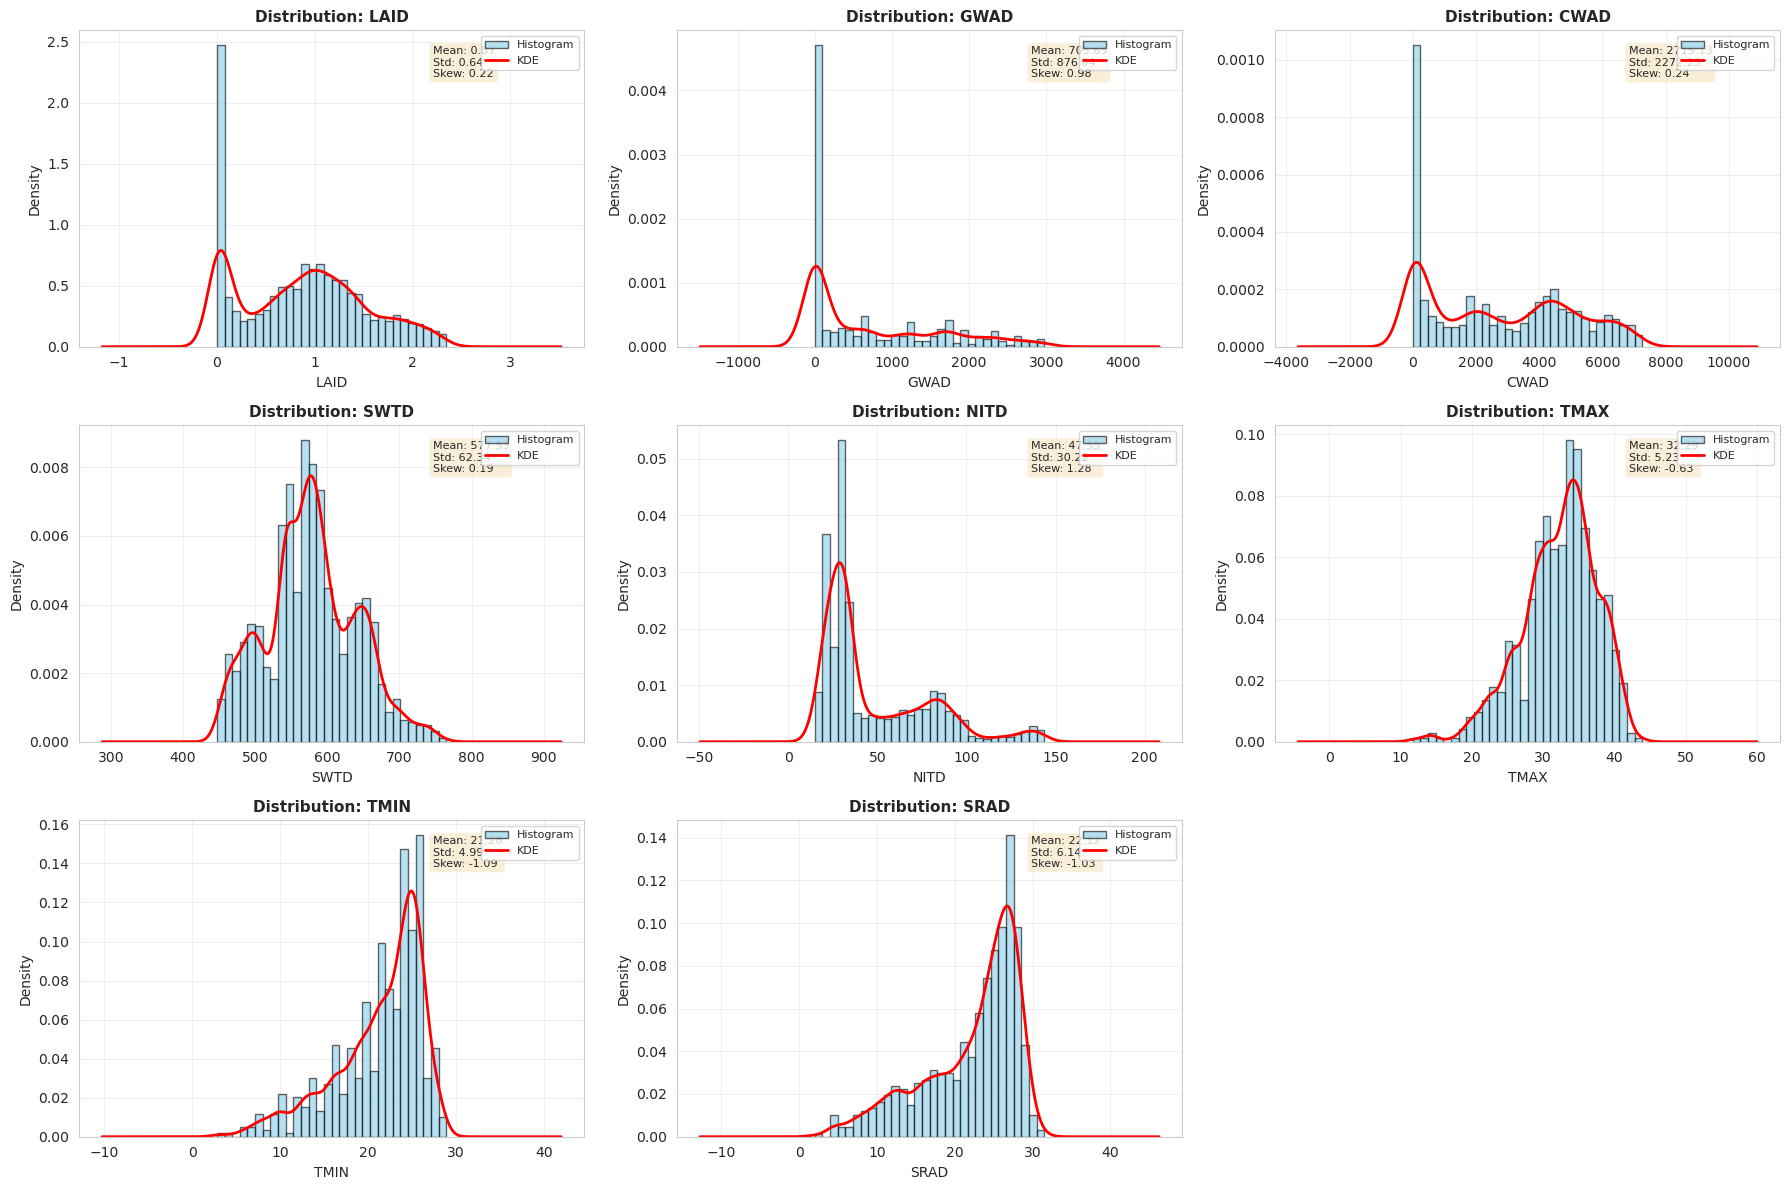


 Skewness Analysis:


,Feature,Skewness
4,NITD,1.280676
6,TMIN,-1.094564
7,SRAD,-1.032017
1,GWAD,0.981354
5,TMAX,-0.630923
2,CWAD,0.243219
0,LAID,0.221569
3,SWTD,0.189885



 Highly skewed features (|skew| > 1): 3
Recommendation: Consider log/sqrt transformation for these features
4.2 FEATURE DISTRIBUTIONS BY GROWTH STAGE

--- How key features vary across growth stages ---


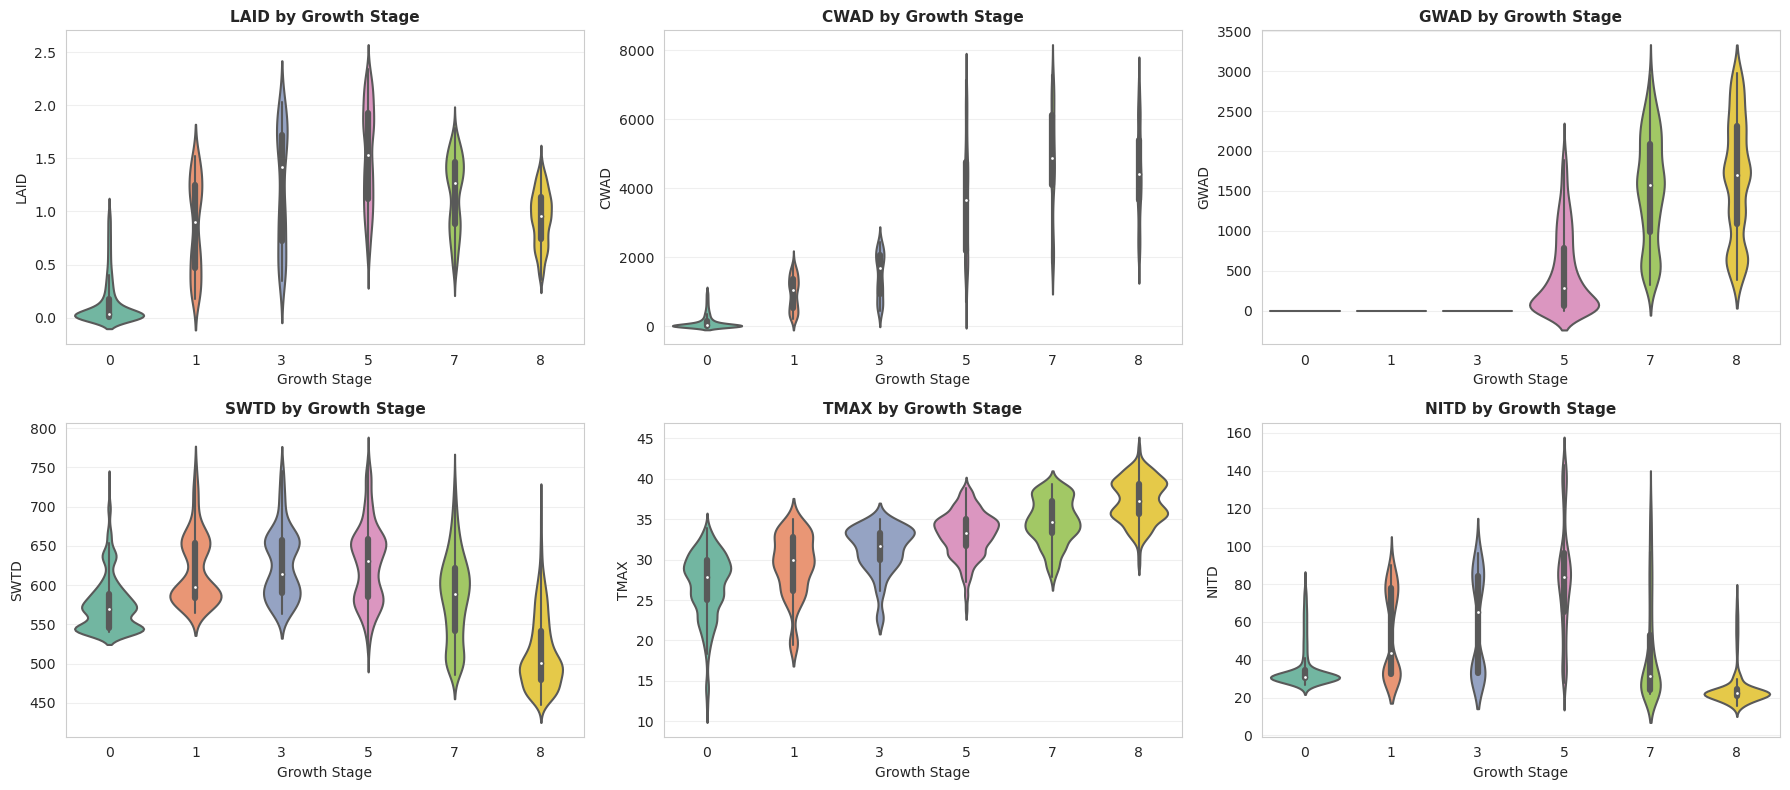


--- 4.3.1 Treatment Performance Comparison ---

 Treatment Performance Rankings:


,Max_Stage,Total_Days,Max_Grain,Max_Biomass,Max_LAI,Grain_per_Day,Stage_Rank,Grain_Rank,Overall_Rank
TRTNA,,,,,,,,,
CRGRO048,8,137,2974,7264,2.35,21.708,1.0,1.0,1.0


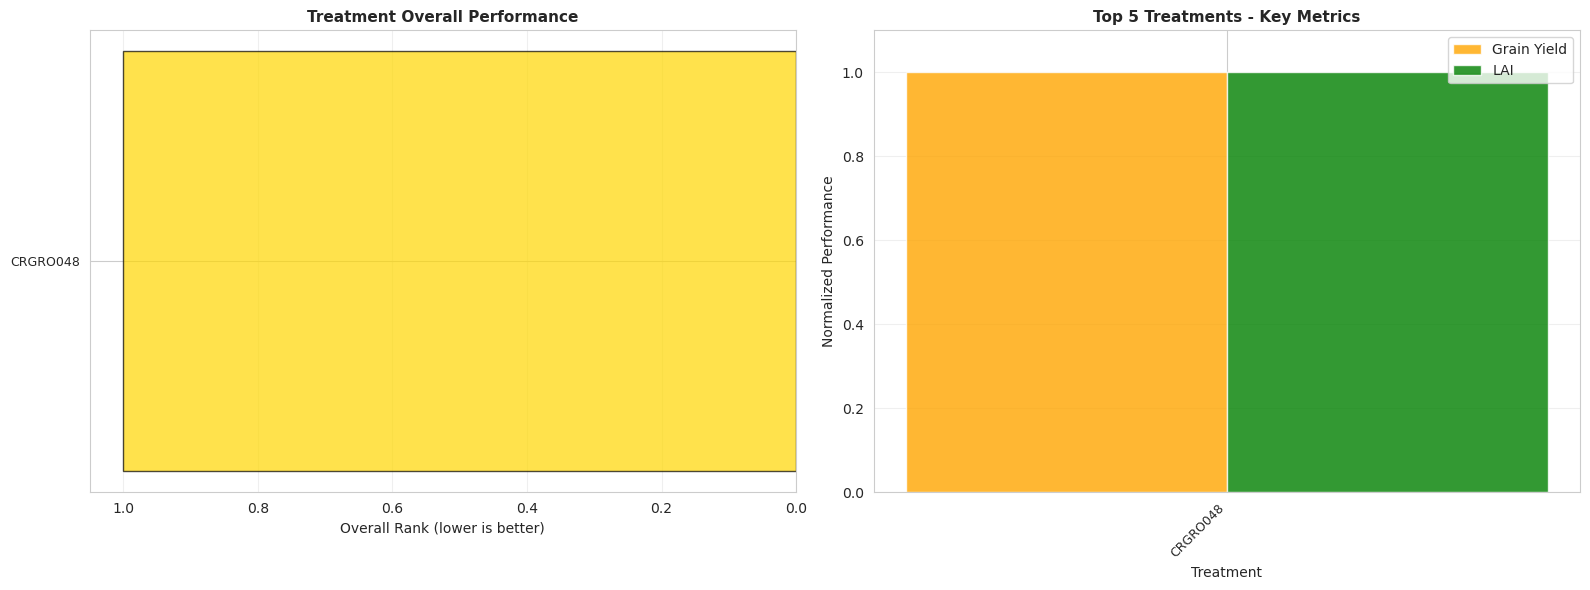


 Key Insights:
Best treatment: CRGRO048 (Rank: 1.0)
Worst treatment: CRGRO048 (Rank: 1.0)
 Grain yield improvement (best vs worst): 0.0%

--- 4.3.2 Treatment Effects on Growth Indicators ---

Mean values by treatment:


,LAID,GWAD,CWAD,GSTD
TRTNA,,,,
CRGRO048,0.87,705.65,2715.13,4.2


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


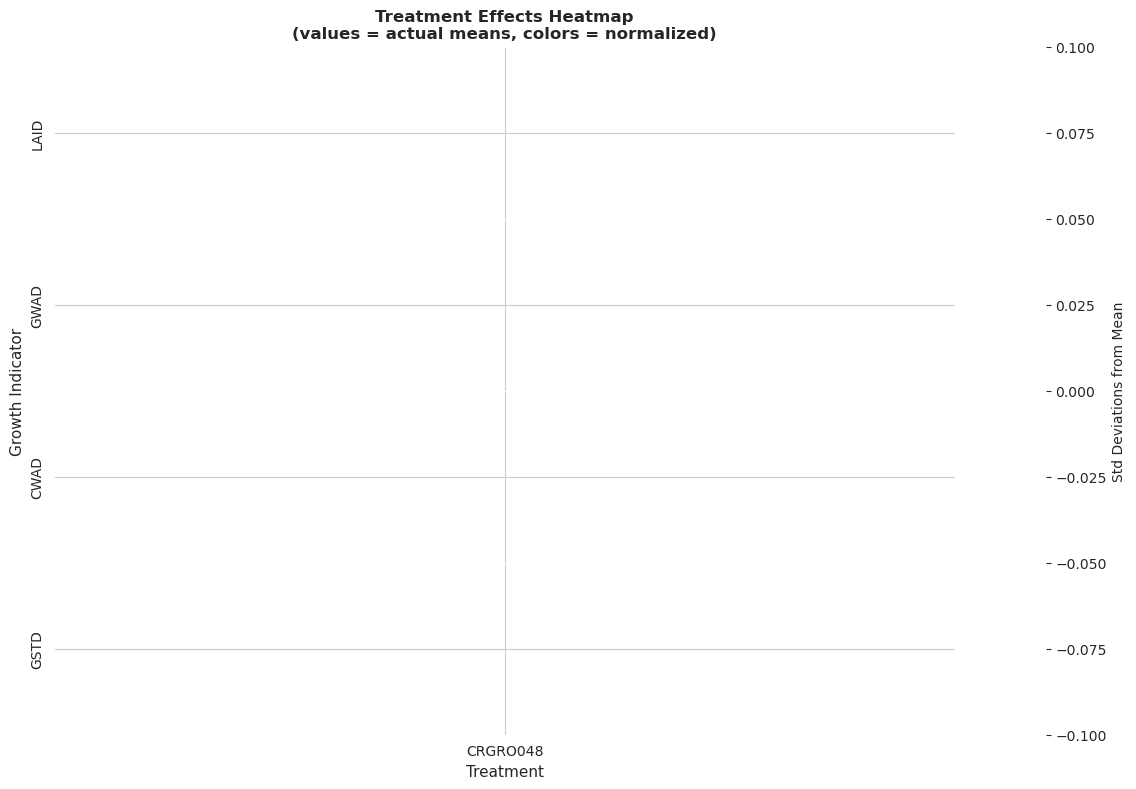


--- 4.3.3 Statistical Significance of Treatment Effects ---


In [8]:
# SECTION 4: FEATURE DISTRIBUTIONS & TREATMENT EFFECTS

print("SECTION 4: FEATURE DISTRIBUTIONS & TREATMENT EFFECTS")

# 4.1 UNIVARIATE DISTRIBUTIONS - KEY FEATURES

print("4.1 UNIVARIATE DISTRIBUTIONS - KEY FEATURES")

key_features = ['LAID', 'GWAD', 'CWAD', 'SWTD', 'NITD', 'TMAX', 'TMIN', 'SRAD']
existing_features = [col for col in key_features if col in df.columns]

if existing_features:
    print(f"\n--- Distribution Analysis for {len(existing_features)} Key Features ---")

    # Create subplots for distributions
    n_features = len(existing_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten() if n_features > 1 else [axes]

    skewness_data = []

    for idx, feature in enumerate(existing_features):
        # Histogram with KDE
        axes[idx].hist(df[feature].dropna(), bins=30, alpha=0.6,
                      color='skyblue', edgecolor='black', density=True, label='Histogram')

        # Add KDE line
        df[feature].dropna().plot(kind='kde', ax=axes[idx], color='red',
                                  linewidth=2, label='KDE')

        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].set_title(f'Distribution: {feature}', fontsize=11, fontweight='bold')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(alpha=0.3)

        # Calculate and store skewness
        skew_val = df[feature].skew()
        skewness_data.append({'Feature': feature, 'Skewness': skew_val})

        # Add statistics text
        stats_text = f"Mean: {df[feature].mean():.2f}\nStd: {df[feature].std():.2f}\nSkew: {skew_val:.2f}"
        axes[idx].text(0.70, 0.95, stats_text, transform=axes[idx].transAxes,
                      fontsize=8, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Hide unused subplots
    for idx in range(len(existing_features), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Skewness summary
    skewness_df = pd.DataFrame(skewness_data).sort_values('Skewness', key=abs, ascending=False)

    print("\n Skewness Analysis:")
    display(skewness_df)

    highly_skewed = skewness_df[abs(skewness_df['Skewness']) > 1]
    if len(highly_skewed) > 0:
        print(f"\n Highly skewed features (|skew| > 1): {len(highly_skewed)}")
        print("Recommendation: Consider log/sqrt transformation for these features")
    else:
        print("\n No highly skewed features detected")

# 4.2 FEATURE DISTRIBUTIONS BY GROWTH STAGE

print("4.2 FEATURE DISTRIBUTIONS BY GROWTH STAGE")

if 'GSTD' in df.columns:
    # Select most important features for stage comparison
    stage_features = ['LAID', 'CWAD', 'GWAD', 'SWTD', 'TMAX', 'NITD']
    stage_features = [f for f in stage_features if f in df.columns]

    if stage_features:
        print("\n--- How key features vary across growth stages ---")

        n_features = len(stage_features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
        axes = axes.flatten() if n_features > 1 else [axes]

        for idx, feature in enumerate(stage_features):
            # Violin plot (shows distribution better than box plot)
            sns.violinplot(data=df, x='GSTD', y=feature, ax=axes[idx], palette='Set2')
            axes[idx].set_xlabel('Growth Stage', fontsize=10)
            axes[idx].set_ylabel(feature, fontsize=10)
            axes[idx].set_title(f'{feature} by Growth Stage', fontsize=11, fontweight='bold')
            axes[idx].grid(axis='y', alpha=0.3)

        # Hide unused subplots
        for idx in range(len(stage_features), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

# 4.3 TREATMENT EFFECTS ANALYSIS

if 'TRTNO' in df.columns and 'TRTNA' in df.columns:

    # 4.3.1 Treatment Performance Metrics

    print("\n--- 4.3.1 Treatment Performance Comparison ---")

    if 'GSTD' in df.columns and 'DAP' in df.columns:
        # Calculate comprehensive performance metrics
        performance_metrics = df.groupby('TRTNA').agg({
            'GSTD': 'max',
            'DAP': 'max',
            'GWAD': 'max' if 'GWAD' in df.columns else 'count',
            'CWAD': 'max' if 'CWAD' in df.columns else 'count',
            'LAID': 'max' if 'LAID' in df.columns else 'count'
        }).round(2)

        performance_metrics.columns = ['Max_Stage', 'Total_Days', 'Max_Grain', 'Max_Biomass', 'Max_LAI']

        # Calculate efficiency metrics
        if 'GWAD' in df.columns:
            performance_metrics['Grain_per_Day'] = (performance_metrics['Max_Grain'] / performance_metrics['Total_Days']).round(3)

        # Ranking
        performance_metrics['Stage_Rank'] = performance_metrics['Max_Stage'].rank(ascending=False)
        if 'GWAD' in df.columns:
            performance_metrics['Grain_Rank'] = performance_metrics['Max_Grain'].rank(ascending=False)
            performance_metrics['Overall_Rank'] = ((performance_metrics['Stage_Rank'] + performance_metrics['Grain_Rank']) / 2).round(1)
        else:
            performance_metrics['Overall_Rank'] = performance_metrics['Stage_Rank']

        performance_metrics = performance_metrics.sort_values('Overall_Rank')

        print("\n Treatment Performance Rankings:")
        display(performance_metrics)

        # Visualize top performers
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Overall ranking
        axes[0].barh(range(len(performance_metrics)),
                    performance_metrics['Overall_Rank'].values,
                    color='gold', alpha=0.7, edgecolor='black')
        axes[0].set_yticks(range(len(performance_metrics)))
        axes[0].set_yticklabels(performance_metrics.index, fontsize=9)
        axes[0].set_xlabel('Overall Rank (lower is better)', fontsize=10)
        axes[0].set_title('Treatment Overall Performance', fontsize=11, fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].invert_xaxis()
        axes[0].grid(axis='x', alpha=0.3)

        # Key metrics comparison
        if 'GWAD' in df.columns and 'LAID' in df.columns:
            top_5 = performance_metrics.head(5)

            x = np.arange(len(top_5))
            width = 0.35

            # Normalize for comparison
            grain_norm = top_5['Max_Grain'] / top_5['Max_Grain'].max()
            lai_norm = top_5['Max_LAI'] / top_5['Max_LAI'].max()

            axes[1].bar(x - width/2, grain_norm, width, label='Grain Yield', alpha=0.8, color='orange')
            axes[1].bar(x + width/2, lai_norm, width, label='LAI', alpha=0.8, color='green')

            axes[1].set_xlabel('Treatment', fontsize=10)
            axes[1].set_ylabel('Normalized Performance', fontsize=10)
            axes[1].set_title('Top 5 Treatments - Key Metrics', fontsize=11, fontweight='bold')
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(top_5.index, rotation=45, ha='right', fontsize=9)
            axes[1].legend()
            axes[1].grid(axis='y', alpha=0.3)
            axes[1].set_ylim([0, 1.1])

        plt.tight_layout()
        plt.show()

        # Insights
        best = performance_metrics.index[0]
        worst = performance_metrics.index[-1]

        print(f"\n Key Insights:")
        print(f"Best treatment: {best} (Rank: {performance_metrics['Overall_Rank'].iloc[0]:.1f})")
        print(f"Worst treatment: {worst} (Rank: {performance_metrics['Overall_Rank'].iloc[-1]:.1f})")

        if 'GWAD' in df.columns:
            grain_improvement = ((performance_metrics.loc[best, 'Max_Grain'] - performance_metrics.loc[worst, 'Max_Grain']) / performance_metrics.loc[worst, 'Max_Grain'] * 100)
            print(f" Grain yield improvement (best vs worst): {grain_improvement:.1f}%")

    # 4.3.2 Treatment Effects on Growth Indicators

    print("\n--- 4.3.2 Treatment Effects on Growth Indicators ---")

    growth_vars = ['LAID', 'GWAD', 'CWAD', 'GSTD']
    growth_vars = [v for v in growth_vars if v in df.columns]

    if growth_vars:
        # Calculate means by treatment
        treatment_means = df.groupby('TRTNA')[growth_vars].mean().round(2)

        print("\nMean values by treatment:")
        display(treatment_means)

        # Heatmap visualization
        fig, ax = plt.subplots(figsize=(12, 8))

        # Normalize for better color scale
        treatment_normalized = (treatment_means - treatment_means.mean()) / treatment_means.std()

        sns.heatmap(treatment_normalized.T, annot=treatment_means.T.values,
                   fmt='.1f', cmap='RdYlGn', center=0,
                   xticklabels=treatment_means.index,
                   yticklabels=treatment_means.columns,
                   cbar_kws={'label': 'Std Deviations from Mean'}, ax=ax,
                   linewidths=0.5)

        ax.set_title('Treatment Effects Heatmap\n(values = actual means, colors = normalized)',
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Treatment', fontsize=11)
        ax.set_ylabel('Growth Indicator', fontsize=11)

        plt.tight_layout()
        plt.show()

    # 4.3.3 Statistical Significance Testing

    print("\n--- 4.3.3 Statistical Significance of Treatment Effects ---")

    from scipy import stats

    test_vars = ['GWAD', 'LAID', 'CWAD', 'GSTD']
    test_vars = [v for v in test_vars if v in df.columns and df['TRTNA'].nunique() > 1]

    if test_vars:
        anova_results = []

        for var in test_vars:
            # Create groups for ANOVA
            groups = [group[var].dropna().values for name, group in df.groupby('TRTNA')]

            # Perform ANOVA
            f_stat, p_value = stats.f_oneway(*groups)

            anova_results.append({
                'Variable': var,
                'F_statistic': round(f_stat, 4),
                'P_value': round(p_value, 6),
                'Significant_at_0.05': 'Yes' if p_value < 0.05 else 'No'
            })

        anova_df = pd.DataFrame(anova_results)

        print("\n ANOVA Test Results - Treatment Effects:")
        display(anova_df)

        significant_count = sum([1 for r in anova_results if r['Significant_at_0.05'] == 'Yes'])
        print(f"\n {significant_count}/{len(test_vars)} variables show statistically significant treatment effects (p < 0.05)")

SECTION 5: MULTIVARIATE PATTERNS & ADVANCED ANALYSIS
5.1 ENVIRONMENTAL INTERACTION EFFECTS

Mean values by Temperature x Water interaction:


GSTD  LAID     CWAD
TMAX_bin  SWTD_bin                       
Low_Temp  Low_Water   0.21  0.05   160.97
          Med_Water   0.76  0.33   606.55
          High_Water  2.34  0.97  1766.55
Med_Temp  Low_Water   6.19  0.82  4041.33
          Med_Water   4.13  1.04  3063.47
          High_Water  5.05  1.44  4069.09
High_Temp Low_Water   7.75  0.86  3722.37
          Med_Water   6.47  1.12  3852.35
          High_Water  6.10  1.50  5030.32

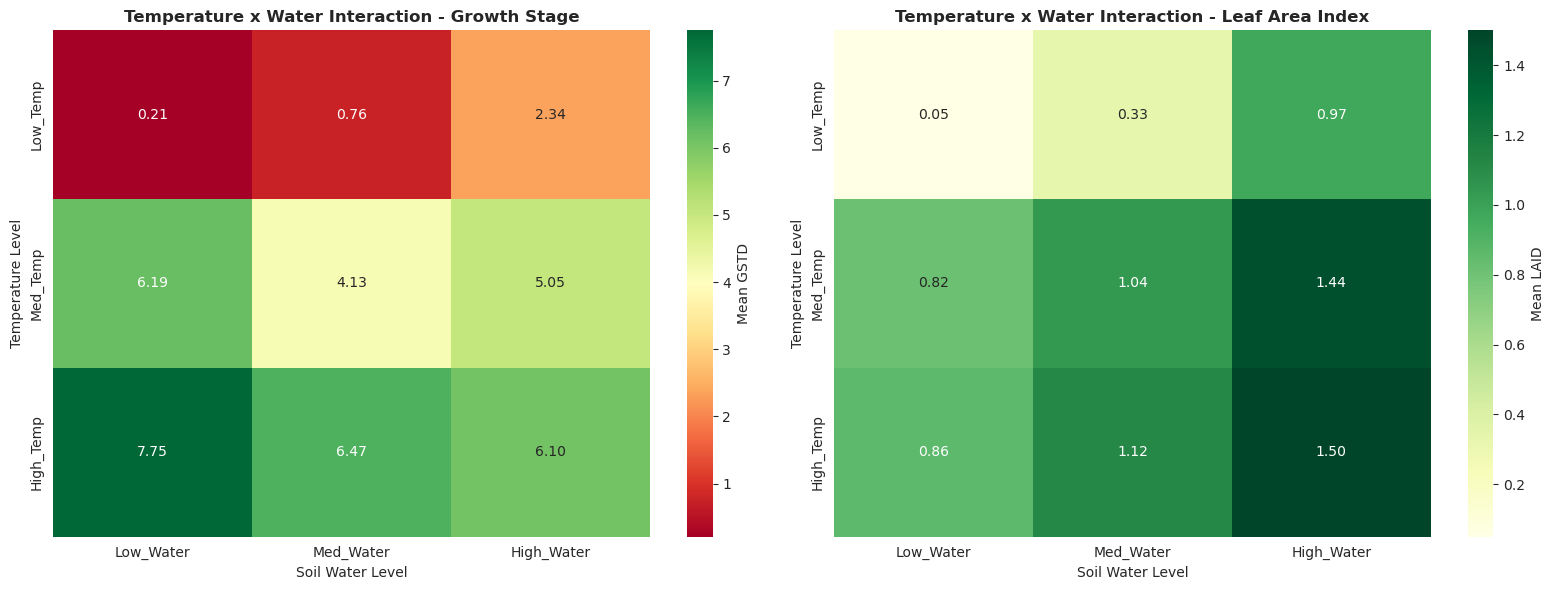

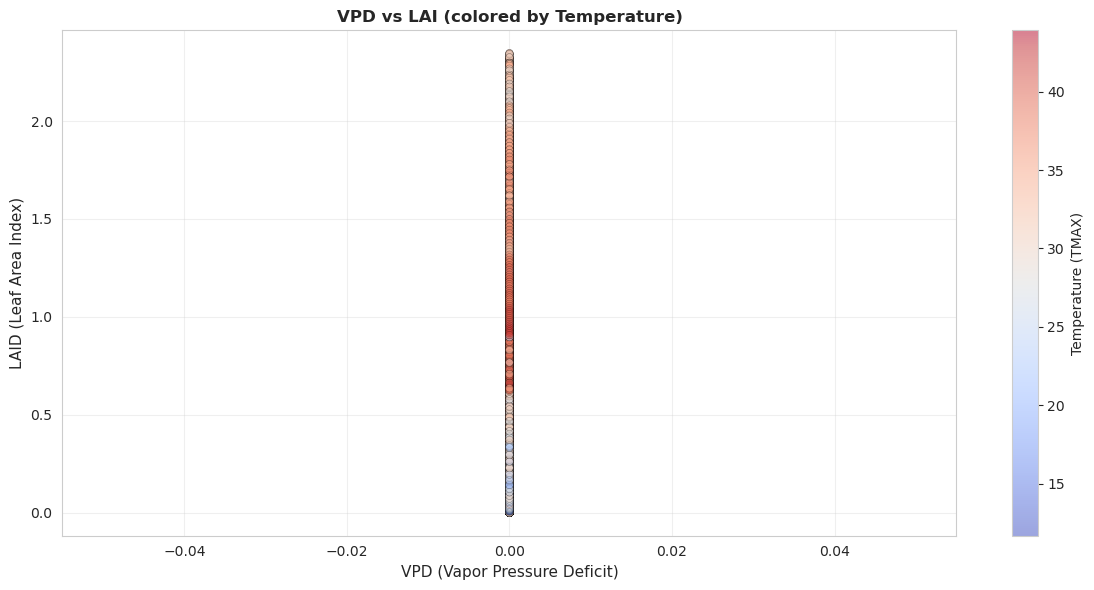

5.2 NUTRIENT x WATER INTERACTION

Mean Biomass (CWAD) by Nitrogen x Water levels:


SWTD_bin,Low_W,Med_W,High_W
NITD_bin,,,
Low_N,3296.53,4286.99,5784.37
Med_N,958.31,775.66,2057.52
High_N,2542.54,2623.97,3571.82


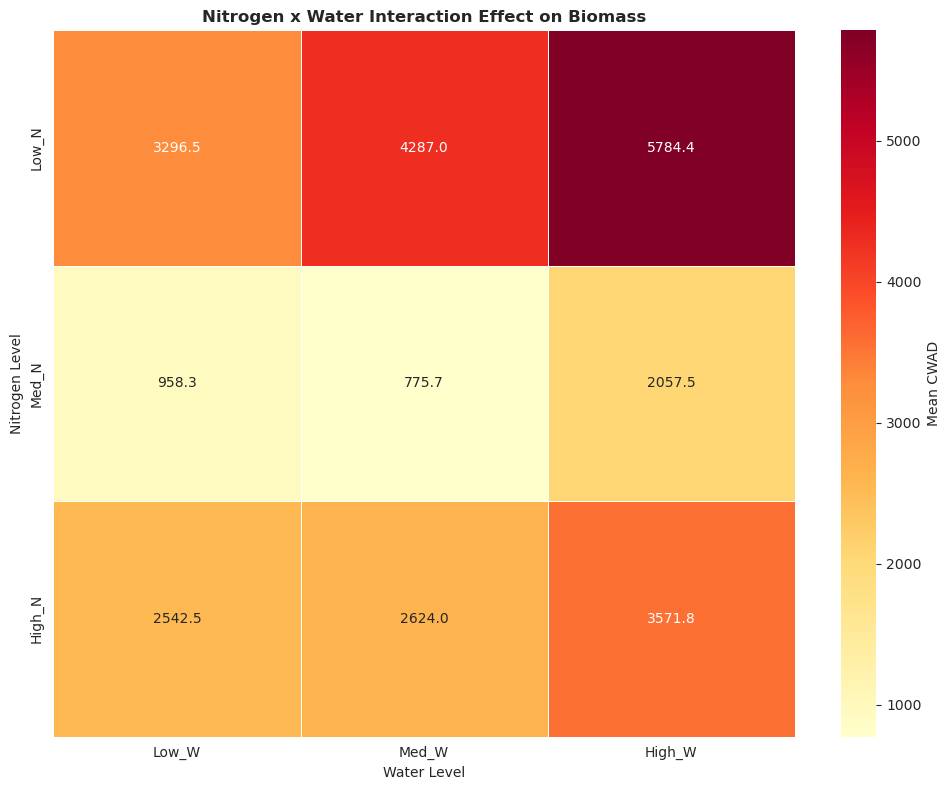

5.3 CLUSTERING ANALYSIS - PLANT BEHAVIOR GROUPS


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


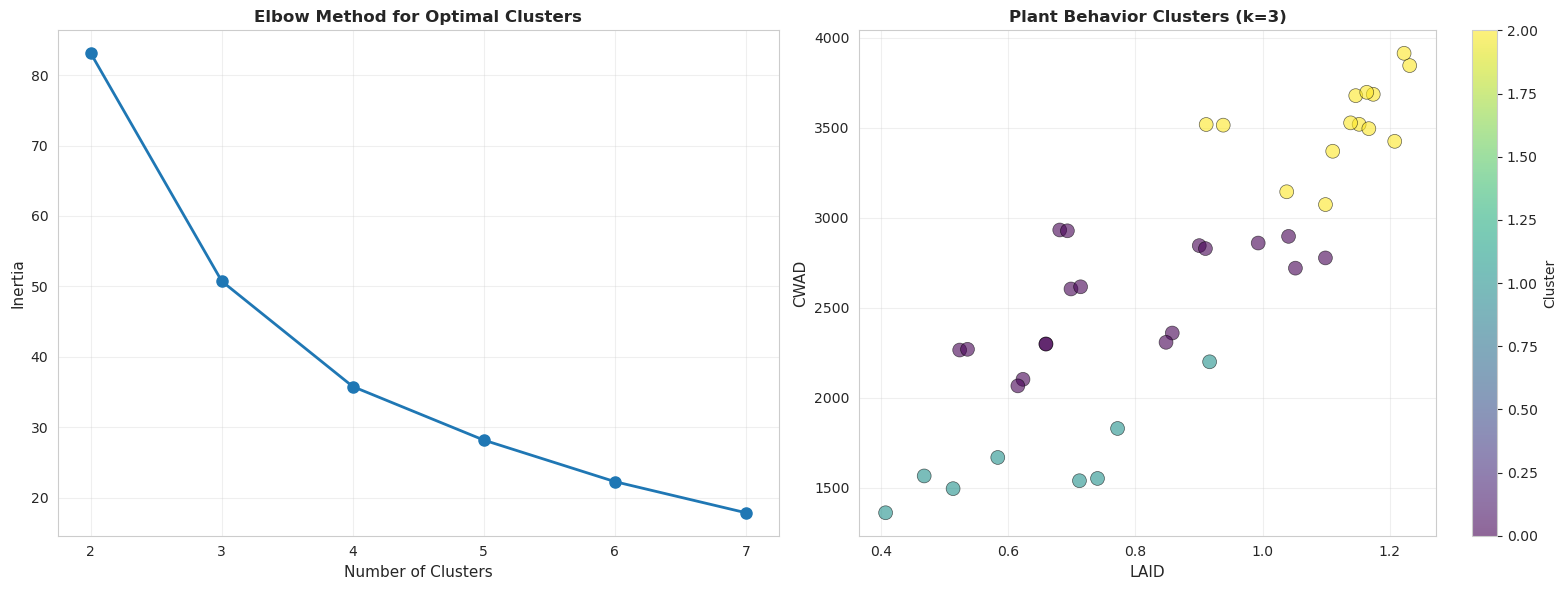


Cluster characteristics (k=3):


,LAID,CWAD,SWTD,TMAX
Cluster,,,,
0,0.78,2554.49,581.12,31.96
1,0.64,1651.42,528.54,34.89
2,1.12,3529.49,600.92,31.23



Cluster sizes:


Cluster
0    18
1     8
2    14
Name: count, dtype: int64

5.4 PRINCIPAL COMPONENT ANALYSIS - DIMENSIONALITY REDUCTION


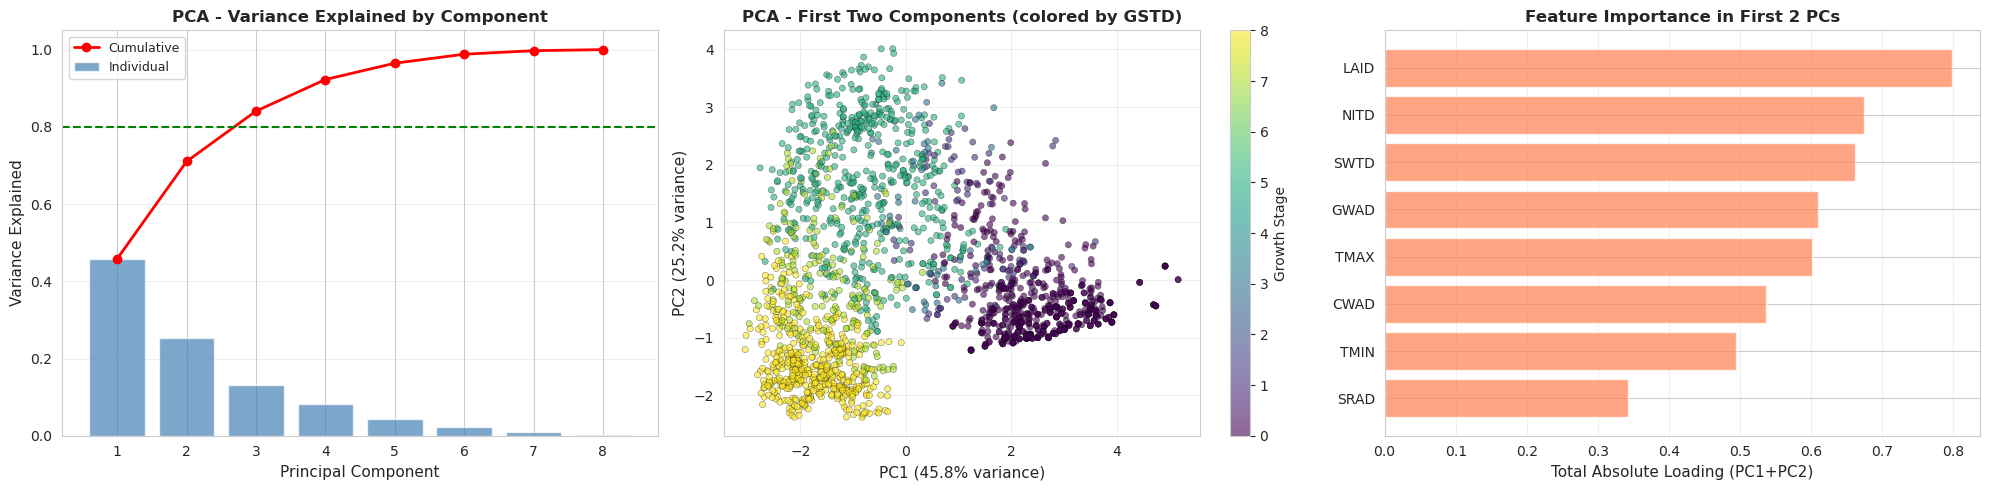


PCA Summary:
Number of components for 80% variance: 3
Total features: 8
Dimensionality reduction: 8 -> 3 (62.5% reduction)


In [9]:
# SECTION 5: MULTIVARIATE PATTERNS & ADVANCED ANALYSIS

print("SECTION 5: MULTIVARIATE PATTERNS & ADVANCED ANALYSIS")

# 5.1 ENVIRONMENTAL INTERACTIONS

print("5.1 ENVIRONMENTAL INTERACTION EFFECTS")

if all(col in df.columns for col in ['TMAX', 'SWTD', 'GSTD']):

    df_temp = df.copy()
    df_temp['TMAX_bin'] = pd.qcut(df_temp['TMAX'], q=3, labels=['Low_Temp', 'Med_Temp', 'High_Temp'])
    df_temp['SWTD_bin'] = pd.qcut(df_temp['SWTD'], q=3, labels=['Low_Water', 'Med_Water', 'High_Water'])

    interaction_table = df_temp.groupby(['TMAX_bin', 'SWTD_bin']).agg({
        'GSTD': 'mean',
        'LAID': 'mean' if 'LAID' in df.columns else 'count',
        'CWAD': 'mean' if 'CWAD' in df.columns else 'count'
    }).round(2)

    print("\nMean values by Temperature x Water interaction:")
    display(interaction_table)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pivot_gstd = interaction_table['GSTD'].unstack()
    sns.heatmap(pivot_gstd, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0],
                cbar_kws={'label': 'Mean GSTD'})
    axes[0].set_title('Temperature x Water Interaction - Growth Stage', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Soil Water Level')
    axes[0].set_ylabel('Temperature Level')

    if 'LAID' in df.columns:
        pivot_lai = interaction_table['LAID'].unstack()
        sns.heatmap(pivot_lai, annot=True, fmt='.2f', cmap='YlGn', ax=axes[1],
                    cbar_kws={'label': 'Mean LAID'})
        axes[1].set_title('Temperature x Water Interaction - Leaf Area Index', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Soil Water Level')
        axes[1].set_ylabel('Temperature Level')

    plt.tight_layout()
    plt.show()

if all(col in df.columns for col in ['VPD', 'TMAX', 'LAID']):

    fig, ax = plt.subplots(figsize=(12, 6))

    scatter = ax.scatter(df['VPD'], df['LAID'], c=df['TMAX'],
                        cmap='coolwarm', alpha=0.5, s=30, edgecolors='k', linewidth=0.3)

    ax.set_xlabel('VPD (Vapor Pressure Deficit)', fontsize=11)
    ax.set_ylabel('LAID (Leaf Area Index)', fontsize=11)
    ax.set_title('VPD vs LAI (colored by Temperature)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Temperature (TMAX)', fontsize=10)

    plt.tight_layout()
    plt.show()

# 5.2 NUTRIENT x WATER AVAILABILITY

print("5.2 NUTRIENT x WATER INTERACTION")

if all(col in df.columns for col in ['NITD', 'SWTD', 'CWAD']):

    df_temp = df.copy()
    df_temp['NITD_bin'] = pd.qcut(df_temp['NITD'], q=3, labels=['Low_N', 'Med_N', 'High_N'], duplicates='drop')
    df_temp['SWTD_bin'] = pd.qcut(df_temp['SWTD'], q=3, labels=['Low_W', 'Med_W', 'High_W'], duplicates='drop')

    nutrient_water = df_temp.groupby(['NITD_bin', 'SWTD_bin'])['CWAD'].mean().unstack()

    print("\nMean Biomass (CWAD) by Nitrogen x Water levels:")
    display(nutrient_water.round(2))

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(nutrient_water, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Mean CWAD'}, linewidths=0.5)
    ax.set_title('Nitrogen x Water Interaction Effect on Biomass', fontsize=12, fontweight='bold')
    ax.set_xlabel('Water Level')
    ax.set_ylabel('Nitrogen Level')

    plt.tight_layout()
    plt.show()

# 5.3 CLUSTERING ANALYSIS - IDENTIFYING PLANT GROUPS

print("5.3 CLUSTERING ANALYSIS - PLANT BEHAVIOR GROUPS")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['LAID', 'CWAD', 'SWTD', 'TMAX']
cluster_features = [f for f in cluster_features if f in df.columns]

if len(cluster_features) >= 3 and 'RUNNO' in df.columns:

    run_aggregates = df.groupby('RUNNO')[cluster_features].mean()

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(run_aggregates)

    inertias = []
    K_range = range(2, 8)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(features_scaled)
        inertias.append(kmeans.inertia_)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters', fontsize=11)
    axes[0].set_ylabel('Inertia', fontsize=11)
    axes[0].set_title('Elbow Method for Optimal Clusters', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)

    optimal_k = 3
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(features_scaled)
    run_aggregates['Cluster'] = clusters

    if len(cluster_features) >= 2:
        scatter = axes[1].scatter(run_aggregates[cluster_features[0]],
                                 run_aggregates[cluster_features[1]],
                                 c=clusters, cmap='viridis', s=100,
                                 alpha=0.6, edgecolors='k', linewidth=0.5)

        axes[1].set_xlabel(cluster_features[0], fontsize=11)
        axes[1].set_ylabel(cluster_features[1], fontsize=11)
        axes[1].set_title(f'Plant Behavior Clusters (k={optimal_k})', fontsize=12, fontweight='bold')
        axes[1].grid(alpha=0.3)

        cbar = plt.colorbar(scatter, ax=axes[1])
        cbar.set_label('Cluster', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\nCluster characteristics (k={optimal_k}):")
    cluster_summary = run_aggregates.groupby('Cluster')[cluster_features].mean()
    display(cluster_summary.round(2))

    cluster_sizes = run_aggregates['Cluster'].value_counts().sort_index()
    print("\nCluster sizes:")
    display(cluster_sizes)

# 5.4 PRINCIPAL COMPONENT ANALYSIS

print("5.4 PRINCIPAL COMPONENT ANALYSIS - DIMENSIONALITY REDUCTION")

from sklearn.decomposition import PCA

pca_features = ['LAID', 'GWAD', 'CWAD', 'SWTD', 'NITD', 'TMAX', 'TMIN', 'SRAD']
pca_features = [f for f in pca_features if f in df.columns]

if len(pca_features) >= 4:

    df_pca = df[pca_features + ['GSTD']].dropna()

    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_pca[pca_features])

    pca = PCA()
    pca_result = pca.fit_transform(features_scaled)

    explained_var = pca.explained_variance_ratio_
    cumsum_var = np.cumsum(explained_var)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, color='steelblue')
    axes[0].plot(range(1, len(explained_var) + 1), cumsum_var, 'r-o', linewidth=2, markersize=6)
    axes[0].set_xlabel('Principal Component', fontsize=11)
    axes[0].set_ylabel('Variance Explained', fontsize=11)
    axes[0].set_title('PCA - Variance Explained by Component', fontsize=12, fontweight='bold')
    axes[0].legend(['Cumulative', 'Individual'], fontsize=9)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, label='80% threshold')

    sample_size = min(2000, len(df_pca))
    sample_indices = np.random.choice(len(df_pca), sample_size, replace=False)

    scatter = axes[1].scatter(pca_result[sample_indices, 0], pca_result[sample_indices, 1],
                             c=df_pca['GSTD'].iloc[sample_indices], cmap='viridis',
                             alpha=0.6, s=20, edgecolors='k', linewidth=0.3)
    axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=11)
    axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=11)
    axes[1].set_title('PCA - First Two Components (colored by GSTD)', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Growth Stage', fontsize=10)

    loadings = pca.components_[:2, :].T
    feature_importance = np.abs(loadings).sum(axis=1)
    feature_importance_df = pd.DataFrame({
        'Feature': pca_features,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=True)

    axes[2].barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
                color='coral', alpha=0.7)
    axes[2].set_xlabel('Total Absolute Loading (PC1+PC2)', fontsize=11)
    axes[2].set_title('Feature Importance in First 2 PCs', fontsize=12, fontweight='bold')
    axes[2].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    n_components_80 = np.argmax(cumsum_var >= 0.8) + 1
    print(f"\nPCA Summary:")
    print(f"Number of components for 80% variance: {n_components_80}")
    print(f"Total features: {len(pca_features)}")
    print(f"Dimensionality reduction: {len(pca_features)} -> {n_components_80} ({(1 - n_components_80/len(pca_features))*100:.1f}% reduction)")

In [10]:
print(f"{df['RUNNO'].nunique()} runs | {df['TRTNO'].nunique()} treatments")

40 runs | 8 treatments


In [11]:
import sys, site
print("python:", sys.executable)
print("site-packages:", site.getsitepackages())
!{sys.executable} -m pip show lightgbm

python: /opt/conda/envs/anaconda-panel-2023.05-py310/bin/python
site-packages: ['/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages']
Name: lightgbm
Version: 4.6.0
Summary: LightGBM Python-package
Home-page: https://github.com/microsoft/LightGBM
Author: 
Author-email: 
License: The MIT License (MIT)

Copyright (c) Microsoft Corporation

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
I

SECTION 7: BASELINE MODEL (NO SAVING)

7.1 PREPARING DATA
Dataset shape after creating target: (5480, 47)
Target distribution (GSTD_Next):
GSTD_Next
0    1655
1     248
3     193
5    1372
7     600
8    1412
Name: count, dtype: int64

7.2 DEFINING BASELINE FEATURES
Baseline features (37):
['TRTNO', 'DAP', 'LAID', 'GSTD', 'GWAD', 'CWAD', 'NIAD', 'NITD', 'NI1D', 'NI2D', 'NI3D', 'NI4D', 'NI5D', 'NI6D', 'NI7D', 'NI8D', 'NI9D', 'SWTD', 'SWXD', 'SW1D', 'SW2D', 'SW3D', 'SW4D', 'SW5D', 'SW6D', 'SW7D', 'SW8D', 'SW9D', 'SW10D', 'SRAD', 'PARD', 'TMAX', 'TMIN', 'VPD', 'TGRD', 'TRTNO_WX', 'LAI']

7.3 TRAIN/TEST SPLIT BY RUNNO
Total runs:  40
Train runs:  32 | Rows: 4384
Test runs:   8  | Rows: 1096

7.4 TRAINING LIGHTGBM BASELINE
Training until validation scores don't improve for 50 rounds
[100]	train's multi_logloss: 0.0012251	val's multi_logloss: 0.00764974
[200]	train's multi_logloss: 8.44311e-06	val's multi_logloss: 0.00444556
Early stopping, best iteration is:
[225]	train's multi_logloss: 4.9

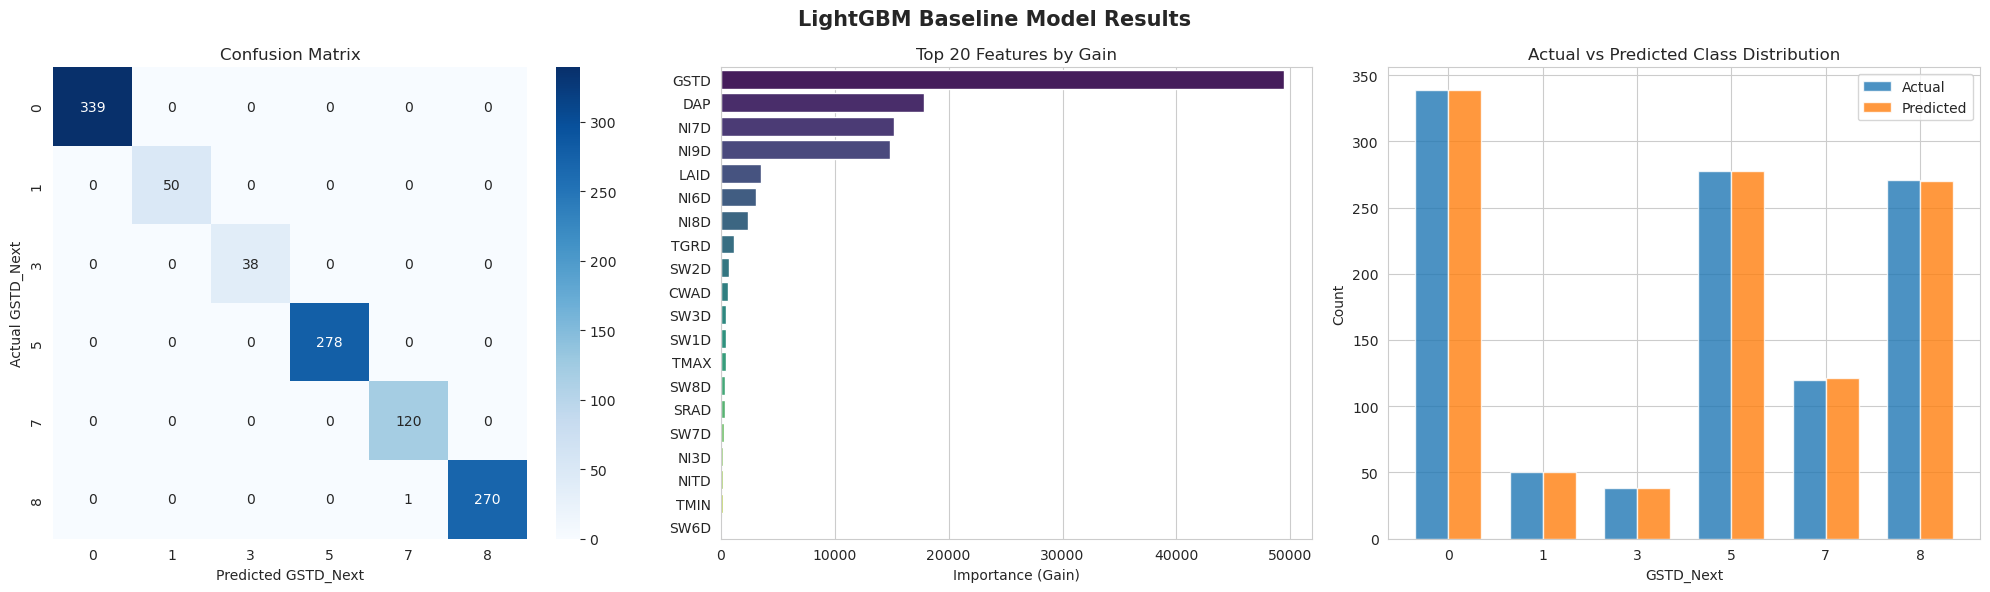


Top 10 features by gain:
Feature  Importance_Gain  Importance_Split
   GSTD     49480.195099              2189
    DAP     17811.543483              4460
   NI7D     15157.209071               832
   NI9D     14880.929214              2327
   LAID      3480.309189              1316
   NI6D      3067.851133               729
   NI8D      2345.112299              1141
   TGRD      1108.605627              1343
   SW2D       710.427045              1455
   CWAD       600.669637              1176

BASELINE MODEL COMPLETE (NO SAVING)
  Accuracy:      99.91%
  F1 (macro):    0.9990
  F1 (weighted): 0.9991


In [12]:
# ============================================================
# SECTION 7: BASELINE MODEL (NO SAVING)
# Target: Next GSTD value (multiclass classification)
# Split: By RUNNO (unseen runs in test set)
# Model: LightGBM
# Features: Original columns only (no engineered features)
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("SECTION 7: BASELINE MODEL (NO SAVING)")
print("=" * 60)

# ─────────────────────────────────────────────
# 7.1 PREPARE DATA
# ─────────────────────────────────────────────
print("\n7.1 PREPARING DATA")

df_model = df.copy()
df_model = df_model.sort_values(['RUNNO', 'DAP']).reset_index(drop=True)

# Create target: next day's GSTD
df_model['GSTD_Next'] = df_model.groupby('RUNNO')['GSTD'].shift(-1)

# Drop last row of each run (no next stage available)
df_model = df_model.dropna(subset=['GSTD_Next'])
df_model['GSTD_Next'] = df_model['GSTD_Next'].astype(int)

print(f"Dataset shape after creating target: {df_model.shape}")
print(f"Target distribution (GSTD_Next):\n{df_model['GSTD_Next'].value_counts().sort_index()}")

# ─────────────────────────────────────────────
# 7.2 DEFINE FEATURES
# ─────────────────────────────────────────────
print("\n7.2 DEFINING BASELINE FEATURES")

drop_cols = [
    'GSTD_Next',      # target
    'TRTNA',          # text version of TRTNO (redundant)
    'TRTNA_x',        # all nulls
    'TRTNA_y',        # all nulls
    'TRTNA_WX',       # all nulls
    'TRTNO_x',        # duplicate of TRTNO
    'TRTNO_y',        # duplicate of TRTNO
    'WDATE',          # date identifier
    'DOY',            # redundant with DAP
    'RUNNO',          # identifier — used for splitting only
]

# Drop only columns that actually exist (prevents KeyError across versions)
drop_cols = [c for c in drop_cols if c in df_model.columns]

feature_cols = [col for col in df_model.columns if col not in drop_cols]

# Handle missing values — forward fill then backfill within each run
df_model[feature_cols] = (
    df_model.groupby('RUNNO')[feature_cols]
    .transform(lambda x: x.ffill().bfill())
)

# Encode any remaining object columns
for col in df_model[feature_cols].select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"Baseline features ({len(feature_cols)}):")
print(feature_cols)

# ─────────────────────────────────────────────
# 7.3 TRAIN / TEST SPLIT BY RUNNO
# ─────────────────────────────────────────────
print("\n7.3 TRAIN/TEST SPLIT BY RUNNO")

all_runs = df_model['RUNNO'].unique()
np.random.seed(42)
n_test_runs = max(1, int(len(all_runs) * 0.2))
test_runs  = np.random.choice(all_runs, size=n_test_runs, replace=False)
train_runs = np.array([r for r in all_runs if r not in test_runs])

train_df = df_model[df_model['RUNNO'].isin(train_runs)]
test_df  = df_model[df_model['RUNNO'].isin(test_runs)]

X_train = train_df[feature_cols]
y_train = train_df['GSTD_Next']
X_test  = test_df[feature_cols]
y_test  = test_df['GSTD_Next']

print(f"Total runs:  {len(all_runs)}")
print(f"Train runs:  {len(train_runs)} | Rows: {len(X_train)}")
print(f"Test runs:   {len(test_runs)}  | Rows: {len(X_test)}")

# ─────────────────────────────────────────────
# 7.4 TRAIN LIGHTGBM BASELINE
# ─────────────────────────────────────────────
print("\n7.4 TRAINING LIGHTGBM BASELINE")

le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc  = le_target.transform(y_test)

params = {
    'objective':         'multiclass',
    'num_class':         len(le_target.classes_),
    'metric':            'multi_logloss',
    'learning_rate':     0.05,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'verbose':           -1,
    'random_state':      42,
}

dtrain = lgb.Dataset(X_train, label=y_train_enc)
dval   = lgb.Dataset(X_test,  label=y_test_enc, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

print(f"\nBest iteration: {model.best_iteration}")

# ─────────────────────────────────────────────
# 7.5 EVALUATE
# ─────────────────────────────────────────────
print("\n7.5 MODEL EVALUATION")

y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_enc   = np.argmax(y_pred_proba, axis=1)
y_pred       = le_target.inverse_transform(y_pred_enc)

acc         = accuracy_score(y_test, y_pred)
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'─'*40}")
print(f"  Accuracy:          {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (macro):        {f1_macro:.4f}")
print(f"  F1 (weighted):     {f1_weighted:.4f}")
print(f"{'─'*40}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────────
# 7.6 PLOTS (DISPLAY ONLY)
# ─────────────────────────────────────────────
print("\n7.6 GENERATING PLOTS (DISPLAY ONLY)")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('LightGBM Baseline Model Results', fontsize=15, fontweight='bold')

# Confusion Matrix
labels_sorted = sorted(pd.Series(y_test).unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted GSTD_Next')
axes[0].set_ylabel('Actual GSTD_Next')

# Feature Importance (top 20)
importance_df = pd.DataFrame({
    'Feature':    model.feature_name(),
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False).head(20)

sns.barplot(
    data=importance_df, y='Feature', x='Importance',
    palette='viridis', ax=axes[1]
)
axes[1].set_title('Top 20 Features by Gain')
axes[1].set_xlabel('Importance (Gain)')
axes[1].set_ylabel('')

# Predicted vs Actual distribution
pred_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
actual_counts = pred_df['Actual'].value_counts().sort_index()
pred_counts   = pred_df['Predicted'].value_counts().sort_index()

x = np.arange(len(actual_counts))
width = 0.35
axes[2].bar(x - width/2, actual_counts.values, width, label='Actual', alpha=0.8)
axes[2].bar(
    x + width/2,
    pred_counts.reindex(actual_counts.index, fill_value=0).values,
    width,
    label='Predicted',
    alpha=0.8
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(actual_counts.index)
axes[2].set_title('Actual vs Predicted Class Distribution')
axes[2].set_xlabel('GSTD_Next')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 7.7 OPTIONAL: VIEW FULL FEATURE IMPORTANCE TABLE (NO SAVE)
# ─────────────────────────────────────────────
full_importance_df = pd.DataFrame({
    'Feature':          model.feature_name(),
    'Importance_Gain':  model.feature_importance(importance_type='gain'),
    'Importance_Split': model.feature_importance(importance_type='split'),
}).sort_values('Importance_Gain', ascending=False)

print("\nTop 10 features by gain:")
print(full_importance_df.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("BASELINE MODEL COMPLETE (NO SAVING)")
print(f"  Accuracy:      {acc*100:.2f}%")
print(f"  F1 (macro):    {f1_macro:.4f}")
print(f"  F1 (weighted): {f1_weighted:.4f}")
print("=" * 60)

In [13]:
# ============================================================
# SECTION 8.1: CLIENT 7-DAY NOTICE LABEL (CORRECT)
# y_trans_7(t) = 1 if ANY GSTD change occurs in (t, t+7]
# ============================================================

import numpy as np
import pandas as pd

H = 7

df_s8 = df.copy().sort_values(["RUNNO", "DAP"]).reset_index(drop=True)

def label_transition_within_horizon(group: pd.DataFrame, horizon: int) -> pd.Series:
    s = group["GSTD"].to_numpy()
    n = len(s)
    y = np.zeros(n, dtype=int)
    for i in range(n):
        j_end = min(n - 1, i + horizon)
        if np.any(s[i+1:j_end+1] != s[i]):
            y[i] = 1
    return pd.Series(y, index=group.index)

df_s8["y_trans_7"] = (
    df_s8.groupby("RUNNO", group_keys=False)
         .apply(lambda g: label_transition_within_horizon(g, H))
)

print("y_trans_7 distribution:")
print(df_s8["y_trans_7"].value_counts())
print("Positive rate:", df_s8["y_trans_7"].mean())

y_trans_7 distribution:
y_trans_7
0    4239
1    1281
Name: count, dtype: int64
Positive rate: 0.23206521739130434


In [14]:
# ============================================================
# SECTION 8.2: HONEST FEATURES + RUNNO SPLIT (NO MODEL YET)
# - Drops leaky columns (GSTD, DAP)
# - Drops IDs/time keys (RUNNO, DOY, WDATE)
# - Drops merge artifacts (_x/_y/_WX)
# - Fills missing values within RUNNO
# - Encodes object columns
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_s8b = df_s8.copy()  # df_s8 already sorted and has y_trans_7

# 1) Drop merge-artifact columns if present
artifact_cols = [c for c in df_s8b.columns if c.endswith("_x") or c.endswith("_y") or c.endswith("_WX")]

# 2) Define drop columns (honest)
drop_cols = [
    "y_trans_7",  # target
    "GSTD",       # leaky
    "DAP",        # leaky proxy
    "RUNNO",      # ID
    "DOY",        # time key (if present)
    "WDATE",      # time key (if present)
    "TRTNA",      # often redundant text label (keep TRTNO numeric if useful)
]
drop_cols = [c for c in drop_cols if c in df_s8b.columns]

# Combine drops
drop_all = list(set(drop_cols + artifact_cols))

feature_cols = [c for c in df_s8b.columns if c not in drop_all]

print(f"# Dropped columns: {len(drop_all)}")
print(f"# Features kept:   {len(feature_cols)}")

# 3) Fill missingness within each run
df_s8b[feature_cols] = (
    df_s8b.groupby("RUNNO")[feature_cols]
          .transform(lambda x: x.ffill().bfill())
)

# 4) Encode object columns (if any)
for col in df_s8b[feature_cols].select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_s8b[col] = le.fit_transform(df_s8b[col].astype(str))

# 5) Train/test split by RUNNO (same style as earlier)
all_runs = df_s8b["RUNNO"].unique()
np.random.seed(42)
n_test_runs = max(1, int(len(all_runs) * 0.2))
test_runs = np.random.choice(all_runs, size=n_test_runs, replace=False)
train_runs = np.array([r for r in all_runs if r not in test_runs])

train_df = df_s8b[df_s8b["RUNNO"].isin(train_runs)]
test_df  = df_s8b[df_s8b["RUNNO"].isin(test_runs)]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df["y_trans_7"].astype(int)
y_test  = test_df["y_trans_7"].astype(int)

print("\nSplit summary:")
print(f"Total runs: {len(all_runs)}")
print(f"Train runs: {len(train_runs)} | rows: {len(train_df)} | pos rate: {y_train.mean():.4f}")
print(f"Test runs:  {len(test_runs)}  | rows: {len(test_df)}  | pos rate: {y_test.mean():.4f}")

# Optional quick check: remaining missingness in features
miss_rate = X_train.isna().mean().sort_values(ascending=False)
print("\nTop remaining missingness (train features):")
print(miss_rate.head(10))

# Dropped columns: 13
# Features kept:   34

Split summary:
Total runs: 40
Train runs: 32 | rows: 4416 | pos rate: 0.2321
Test runs:  8  | rows: 1104  | pos rate: 0.2319

Top remaining missingness (train features):
TRTNO    0.0
SW9D     0.0
SW3D     0.0
SW4D     0.0
SW5D     0.0
SW6D     0.0
SW7D     0.0
SW8D     0.0
SW10D    0.0
LAID     0.0
dtype: float64


SECTION 8.3: LIGHTGBM HONEST BASELINE — 7-DAY NOTICE
Train positives: 1025 | negatives: 3391 | scale_pos_weight: 3.31
[200]	train's binary_logloss: 0.00451782	val's binary_logloss: 0.0204899
[400]	train's binary_logloss: 0.000184312	val's binary_logloss: 0.00977775
Best iteration: 526

=== RESULTS (Threshold = 0.50) ===
Accuracy:       0.9973
F1:             0.9942
ROC-AUC:        1.0000
Avg Precision:  0.9999

Classification Report:
                   precision    recall  f1-score   support

No Transition ≤7d       1.00      1.00      1.00       848
   Transition ≤7d       0.99      1.00      0.99       256

         accuracy                           1.00      1104
        macro avg       0.99      1.00      1.00      1104
     weighted avg       1.00      1.00      1.00      1104



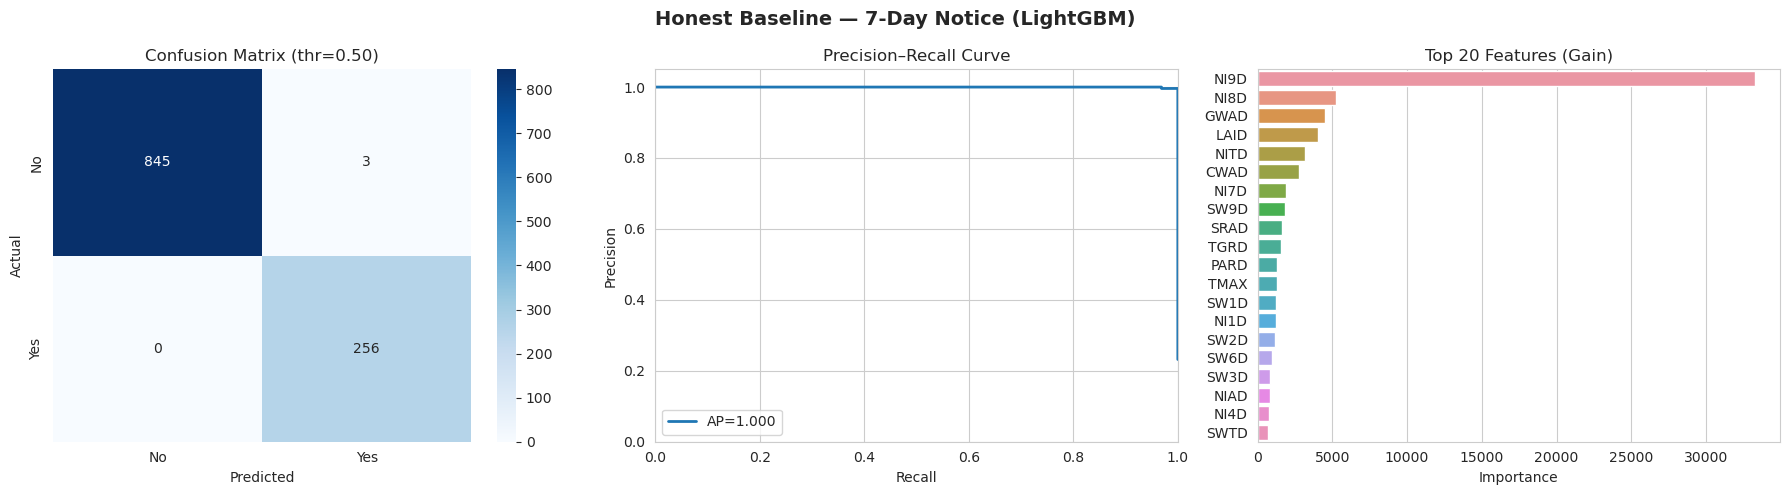


Top 10 features by gain:
Feature   Importance
   NI9D 33276.307581
   NI8D  5224.047847
   GWAD  4479.704136
   LAID  4050.127285
   NITD  3182.338892
   CWAD  2778.595655
   NI7D  1899.655443
   SW9D  1837.296900
   SRAD  1648.651776
   TGRD  1573.214660


In [15]:
# ============================================================
# SECTION 8.3: LIGHTGBM BASELINE — 7-DAY NOTICE (HONEST)
# Target: y_trans_7
# Split:  By RUNNO (already created)
# Model:  LightGBM binary
# Metrics: Average Precision (PR-AUC), ROC-AUC, F1, report
# ============================================================

import lightgbm as lgb
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("SECTION 8.3: LIGHTGBM HONEST BASELINE — 7-DAY NOTICE")
print("=" * 70)

# ---- class imbalance handling
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / max(pos, 1)
print(f"Train positives: {pos} | negatives: {neg} | scale_pos_weight: {scale_pos:.2f}")

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": scale_pos,
    "verbose": -1,
    "random_state": 42,
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=200),
]

model_7d = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=callbacks,
)

print("Best iteration:", model_7d.best_iteration)

# ---- predictions
y_proba = model_7d.predict(X_test, num_iteration=model_7d.best_iteration)
y_pred  = (y_proba >= 0.5).astype(int)

# ---- metrics
acc      = accuracy_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_proba) if y_test.nunique() > 1 else np.nan
avg_prec = average_precision_score(y_test, y_proba)

print("\n=== RESULTS (Threshold = 0.50) ===")
print(f"Accuracy:       {acc:.4f}")
print(f"F1:             {f1:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"Avg Precision:  {avg_prec:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Transition ≤7d", "Transition ≤7d"]))

# ---- plots (display only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Honest Baseline — 7-Day Notice (LightGBM)", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (thr=0.50)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Precision–Recall curve
precision, recall, thr = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, lw=2, label=f"AP={avg_prec:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

# Feature importance (Top 20)
imp = pd.DataFrame({
    "Feature": model_7d.feature_name(),
    "Importance": model_7d.feature_importance(importance_type="gain"),
}).sort_values("Importance", ascending=False)

top = imp.head(20)
sns.barplot(data=top, y="Feature", x="Importance", ax=axes[2])
axes[2].set_title("Top 20 Features (Gain)")
axes[2].set_xlabel("Importance")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

print("\nTop 10 features by gain:")
print(imp.head(10).to_string(index=False))

In [16]:
# ============================================================
# SECTION 8.4: LEAKAGE / PROXY AUDIT (ONE STEP)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

print("="*70)
print("SECTION 8.4: AUDIT FOR TIME/PROXY FEATURES")
print("="*70)

# 1) single-feature AUC (how well each feature alone predicts y_trans_7)
rows = []
y = df_s8b["y_trans_7"].astype(int)

for col in feature_cols:
    x = df_s8b[col]
    if x.nunique(dropna=True) <= 1:
        continue
    if not pd.api.types.is_numeric_dtype(x):
        continue
    try:
        auc = roc_auc_score(y, x)
        auc = max(auc, 1 - auc)   # take absolute (direction-free)
        rows.append((col, auc, float(x.isna().mean())))
    except Exception:
        pass

single_auc = pd.DataFrame(rows, columns=["feature", "abs_auc", "missing_rate"]) \
             .sort_values("abs_auc", ascending=False)

print("\nTop 20 single-feature AUCs (higher = more suspicious):")
print(single_auc.head(20).to_string(index=False))

# 2) correlation with DAP (time proxy check)
if "DAP" in df.columns:
    tmp = df_s8b.copy()
    tmp["DAP"] = df.loc[df_s8b.index, "DAP"].values  # align by index (same sort)
    corr_rows = []
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(tmp[col]) and tmp[col].nunique() > 1:
            c = tmp[[col, "DAP"]].corr(method="spearman").iloc[0,1]
            if pd.notna(c):
                corr_rows.append((col, abs(c)))
    corr_with_dap = pd.DataFrame(corr_rows, columns=["feature", "abs_spearman_with_DAP"]) \
                    .sort_values("abs_spearman_with_DAP", ascending=False)

    print("\nTop 20 features most correlated with DAP (time proxy):")
    print(corr_with_dap.head(20).to_string(index=False))

print("\nDone.")

SECTION 8.4: AUDIT FOR TIME/PROXY FEATURES

Top 20 single-feature AUCs (higher = more suspicious):
feature  abs_auc  missing_rate
   SW4D 0.691709           0.0
   SW5D 0.690724           0.0
   SWXD 0.685875           0.0
   SWTD 0.685662           0.0
   SW3D 0.681321           0.0
   SW6D 0.672055           0.0
   NI8D 0.669366           0.0
   SW2D 0.665051           0.0
   NITD 0.654020           0.0
   NIAD 0.650237           0.0
   NI4D 0.642391           0.0
   NI7D 0.636945           0.0
   SW1D 0.635423           0.0
   NI6D 0.631536           0.0
   NI5D 0.628480           0.0
   SW7D 0.621260           0.0
   NI3D 0.614724           0.0
   SW8D 0.602413           0.0
    LAI 0.590462           0.0
   LAID 0.590462           0.0

Top 20 features most correlated with DAP (time proxy):
feature  abs_spearman_with_DAP
   GWAD               0.904604
   CWAD               0.850207
   TGRD               0.837718
   TMAX               0.812624
   TMIN               0.810577
   NI9D 

In [17]:
# ============================================================
# SECTION 8.5: GROUPK-FOLD CV (BY RUNNO) FOR 7-DAY NOTICE
# Reports cross-validated performance (more credible than 1 split)
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

print("="*70)
print("SECTION 8.5: GROUPK-FOLD CV (RUNNO) — 7-DAY NOTICE")
print("="*70)

X = df_s8b[feature_cols]
y = df_s8b["y_trans_7"].astype(int)
groups = df_s8b["RUNNO"]

gkf = GroupKFold(n_splits=5)

ap_scores = []
roc_scores = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale_pos = neg / max(pos, 1)

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "scale_pos_weight": scale_pos,
        "verbose": -1,
        "random_state": 42,
    }

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    proba = model.predict(X_va, num_iteration=model.best_iteration)

    ap = average_precision_score(y_va, proba)
    roc = roc_auc_score(y_va, proba) if y_va.nunique() > 1 else np.nan

    ap_scores.append(ap)
    roc_scores.append(roc)

    print(f"Fold {fold}: AP={ap:.4f}, ROC-AUC={roc:.4f}, val_pos_rate={y_va.mean():.4f}")

print("\n=== CV SUMMARY (5-fold, grouped by RUNNO) ===")
print(f"Avg Precision (AP): mean={np.mean(ap_scores):.4f}, std={np.std(ap_scores):.4f}")
print(f"ROC-AUC:            mean={np.nanmean(roc_scores):.4f}, std={np.nanstd(roc_scores):.4f}")

SECTION 8.5: GROUPK-FOLD CV (RUNNO) — 7-DAY NOTICE
Fold 1: AP=0.9826, ROC-AUC=0.9941, val_pos_rate=0.2319
Fold 2: AP=0.9966, ROC-AUC=0.9989, val_pos_rate=0.2319
Fold 3: AP=0.9875, ROC-AUC=0.9962, val_pos_rate=0.2319
Fold 4: AP=0.9871, ROC-AUC=0.9959, val_pos_rate=0.2319
Fold 5: AP=0.9944, ROC-AUC=0.9982, val_pos_rate=0.2328

=== CV SUMMARY (5-fold, grouped by RUNNO) ===
Avg Precision (AP): mean=0.9896, std=0.0051
ROC-AUC:            mean=0.9967, std=0.0017


In [18]:
# ============================================================
# SECTION 8.6: THRESHOLD SELECTION FOR 7-DAY NOTICE ALERTS
# Goal: pick threshold based on recall target (client-friendly)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, confusion_matrix

# If y_proba isn't in memory (new kernel), recompute quickly:
try:
    _ = y_proba
except NameError:
    y_proba = model_7d.predict(X_test, num_iteration=model_7d.best_iteration)

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# precision_recall_curve returns thresholds length = len(precision)-1
pr_df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall
}).sort_values("threshold")

def best_threshold_for_recall(target_recall: float) -> pd.Series:
    # among thresholds meeting recall, choose the one with highest precision
    candidates = pr_df[pr_df["recall"] >= target_recall]
    if len(candidates) == 0:
        return pd.Series({"threshold": np.nan, "precision": np.nan, "recall": np.nan})
    best = candidates.sort_values(["precision", "threshold"], ascending=[False, False]).iloc[0]
    return best

targets = [0.90, 0.95, 0.98]
rows = []
for t in targets:
    best = best_threshold_for_recall(t)
    rows.append([t, float(best["threshold"]), float(best["precision"]), float(best["recall"])])

out = pd.DataFrame(rows, columns=["recall_target", "threshold", "precision", "recall"])
print("Threshold options (choose based on desired recall):")
print(out.to_string(index=False))

# Also show confusion matrix for the 0.95 recall option (typical choice)
chosen_thr = out.loc[out["recall_target"] == 0.95, "threshold"].values[0]
y_pred_thr = (y_proba >= chosen_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_thr)

print(f"\nConfusion matrix at threshold={chosen_thr:.4f} (target recall 0.95):")
print(cm)
print("Rows=Actual [No, Yes], Cols=Pred [No, Yes]")

Threshold options (choose based on desired recall):
 recall_target  threshold  precision   recall
          0.90   0.997892   1.000000 0.902344
          0.95   0.985853   1.000000 0.953125
          0.98   0.717868   0.996109 1.000000

Confusion matrix at threshold=0.9859 (target recall 0.95):
[[848   0]
 [ 12 244]]
Rows=Actual [No, Yes], Cols=Pred [No, Yes]


In [19]:
# ============================================================
# PRIMARY ALL-TREATMENTS: REPORT-READY SUMMARY
# ============================================================

import numpy as np
import pandas as pd

summary = pd.DataFrame({
    "Fold": list(range(1, len(ap_scores)+1)),
    "AP": ap_scores,
    "ROC_AUC": roc_scores
})

print("Per-fold performance (GroupKFold by RUNNO):")
display(summary)

print("\nCV Summary:")
print(f"AP mean={np.mean(ap_scores):.4f}, std={np.std(ap_scores):.4f}")
print(f"ROC-AUC mean={np.nanmean(roc_scores):.4f}, std={np.nanstd(roc_scores):.4f}")

# If you still have your threshold table 'out' from Step 8.6:
try:
    print("\nSuggested alert thresholds (from holdout split):")
    display(out)
except NameError:
    print("\n(Threshold table 'out' not found in memory — that's okay.)")

Per-fold performance (GroupKFold by RUNNO):


,Fold,AP,ROC_AUC
0,1,0.982587,0.994099
1,2,0.996576,0.998904
2,3,0.987522,0.996177
3,4,0.987063,0.995946
4,5,0.994416,0.998185



CV Summary:
AP mean=0.9896, std=0.0051
ROC-AUC mean=0.9967, std=0.0017

Suggested alert thresholds (from holdout split):


,recall_target,threshold,precision,recall
0,0.90,0.997892,1.000000,0.902344
1,0.95,0.985853,1.000000,0.953125
2,0.98,0.717868,0.996109,1.000000


In [20]:
# ============================================================
# SECTION 9.1: LEAVE-ONE-TREATMENT-OUT (LOTO) GENERALIZATION TEST
# Train on 7 treatments, test on the held-out treatment
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

print("="*70)
print("SECTION 9.1: LEAVE-ONE-TREATMENT-OUT GENERALIZATION (TRTNO)")
print("="*70)

X_all = df_s8b[feature_cols]
y_all = df_s8b["y_trans_7"].astype(int)
trt_all = df_s8b["TRTNO"].astype(int)

treatments = sorted(trt_all.unique())

rows = []

for trt_holdout in treatments:
    test_idx = trt_all == trt_holdout
    train_idx = ~test_idx

    X_tr, X_te = X_all.loc[train_idx], X_all.loc[test_idx]
    y_tr, y_te = y_all.loc[train_idx], y_all.loc[test_idx]

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale_pos = neg / max(pos, 1)

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "scale_pos_weight": scale_pos,
        "verbose": -1,
        "random_state": 42,
    }

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_te, label=y_te, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    proba = model.predict(X_te, num_iteration=model.best_iteration)

    ap = average_precision_score(y_te, proba)
    roc = roc_auc_score(y_te, proba) if y_te.nunique() > 1 else np.nan

    rows.append({
        "TRTNO_holdout": trt_holdout,
        "test_rows": int(test_idx.sum()),
        "test_pos_rate": float(y_te.mean()),
        "AP": float(ap),
        "ROC_AUC": float(roc),
    })

    print(f"Holdout TRTNO={trt_holdout}: rows={test_idx.sum()}, pos_rate={y_te.mean():.3f}, AP={ap:.4f}, ROC-AUC={roc:.4f}")

loto_df = pd.DataFrame(rows).sort_values("TRTNO_holdout")
print("\n=== LOTO SUMMARY ===")
display(loto_df)

print("\nMean across treatments:")
print(f"AP mean={loto_df['AP'].mean():.4f}, std={loto_df['AP'].std():.4f}")
print(f"ROC-AUC mean={loto_df['ROC_AUC'].mean():.4f}, std={loto_df['ROC_AUC'].std():.4f}")

SECTION 9.1: LEAVE-ONE-TREATMENT-OUT GENERALIZATION (TRTNO)
Holdout TRTNO=1: rows=690, pos_rate=0.232, AP=0.9998, ROC-AUC=0.9999
Holdout TRTNO=2: rows=690, pos_rate=0.232, AP=0.9997, ROC-AUC=0.9999
Holdout TRTNO=3: rows=690, pos_rate=0.232, AP=0.9976, ROC-AUC=0.9993
Holdout TRTNO=4: rows=690, pos_rate=0.232, AP=1.0000, ROC-AUC=1.0000
Holdout TRTNO=5: rows=690, pos_rate=0.232, AP=0.9998, ROC-AUC=0.9999
Holdout TRTNO=6: rows=690, pos_rate=0.232, AP=0.9998, ROC-AUC=0.9999
Holdout TRTNO=7: rows=690, pos_rate=0.233, AP=0.9586, ROC-AUC=0.9820
Holdout TRTNO=8: rows=690, pos_rate=0.232, AP=0.9721, ROC-AUC=0.9910

=== LOTO SUMMARY ===


,TRTNO_holdout,test_rows,test_pos_rate,AP,ROC_AUC
0,1,690,0.231884,0.999808,0.999941
1,2,690,0.231884,0.999691,0.999906
2,3,690,0.231884,0.997595,0.999281
3,4,690,0.231884,1.000000,1.000000
4,5,690,0.231884,0.999803,0.999941
5,6,690,0.231884,0.999774,0.999929
6,7,690,0.233333,0.958630,0.982024
7,8,690,0.231884,0.972095,0.990967



Mean across treatments:
AP mean=0.9909, std=0.0162
ROC-AUC mean=0.9965, std=0.0066


In [21]:
# ============================================================
# SECTION 10.1: TIME-SERIES FEATURE ENGINEERING (LAGS/ROLLING)
# Leakage-safe: computed within RUNNO using past values only
# ============================================================

import numpy as np
import pandas as pd

df_ts = df_s8.copy()  # has y_trans_7 and is sorted by RUNNO, DAP

# Pick variables to engineer (start with top drivers + key weather/plant vars)
base_vars = [
    "LAID", "LAI",
    "NI8D", "NI9D",
    "SWTD", "SWXD", "SW1D", "SW2D", "SW3D",
    "TMAX", "TMIN", "SRAD", "PARD", "VPD",
    "GWAD", "CWAD"
]
base_vars = [v for v in base_vars if v in df_ts.columns]

lags = [1, 3, 7]
roll_window = 7

def add_ts_features(g: pd.DataFrame) -> pd.DataFrame:
    g = g.copy()
    for v in base_vars:
        # lags
        for L in lags:
            g[f"{v}_lag{L}"] = g[v].shift(L)
        # deltas
        g[f"{v}_d1"] = g[v] - g[v].shift(1)
        g[f"{v}_d7"] = g[v] - g[v].shift(7)
        # rolling stats (use shift(1) so today's value not included in the window)
        g[f"{v}_roll{roll_window}_mean"] = g[v].shift(1).rolling(roll_window, min_periods=1).mean()
        g[f"{v}_roll{roll_window}_std"]  = g[v].shift(1).rolling(roll_window, min_periods=1).std()
    return g

df_ts = df_ts.groupby("RUNNO", group_keys=False).apply(add_ts_features)

print("Added TS features. New shape:", df_ts.shape)
print("Example TS columns:", [c for c in df_ts.columns if "_lag" in c or "_roll" in c or c.endswith("_d1")][:20])

Added TS features. New shape: (5520, 159)
Example TS columns: ['LAID_lag1', 'LAID_lag3', 'LAID_lag7', 'LAID_d1', 'LAID_roll7_mean', 'LAID_roll7_std', 'LAI_lag1', 'LAI_lag3', 'LAI_lag7', 'LAI_d1', 'LAI_roll7_mean', 'LAI_roll7_std', 'NI8D_lag1', 'NI8D_lag3', 'NI8D_lag7', 'NI8D_d1', 'NI8D_roll7_mean', 'NI8D_roll7_std', 'NI9D_lag1', 'NI9D_lag3']


In [22]:
# ============================================================
# SECTION 10.2: HONEST TS MODEL (LAGS/ROLLING) + GROUPK-FOLD CV
# - Uses df_ts (with engineered features) and y_trans_7
# - Drops leaky cols (GSTD, DAP) + IDs/time keys
# - Fills missingness within RUNNO
# - Runs GroupKFold CV by RUNNO and reports mean/std AP & ROC-AUC
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("SECTION 10.2: TS FEATURES + GROUPK-FOLD CV (RUNNO)")
print("="*70)

df_ts2 = df_ts.copy()

# Drop merge artifacts if any exist
artifact_cols = [c for c in df_ts2.columns if c.endswith("_x") or c.endswith("_y") or c.endswith("_WX")]

drop_cols = [
    "y_trans_7",
    "GSTD", "DAP",
    "RUNNO",
    "DOY", "WDATE",
    "TRTNA",
]
drop_cols = [c for c in drop_cols if c in df_ts2.columns]

drop_all = list(set(drop_cols + artifact_cols))
feature_cols_ts = [c for c in df_ts2.columns if c not in drop_all]

# Fill missingness within RUNNO (lags create NaNs at start of each run)
df_ts2[feature_cols_ts] = (
    df_ts2.groupby("RUNNO")[feature_cols_ts]
          .transform(lambda x: x.ffill().bfill())
)

# Encode any object columns
for col in df_ts2[feature_cols_ts].select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_ts2[col] = le.fit_transform(df_ts2[col].astype(str))

X = df_ts2[feature_cols_ts]
y = df_ts2["y_trans_7"].astype(int)
groups = df_ts2["RUNNO"]

print(f"# TS features used: {len(feature_cols_ts)}")

gkf = GroupKFold(n_splits=5)

ap_scores_ts = []
roc_scores_ts = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale_pos = neg / max(pos, 1)

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "scale_pos_weight": scale_pos,
        "verbose": -1,
        "random_state": 42,
    }

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_va, label=y_va, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    proba = model.predict(X_va, num_iteration=model.best_iteration)

    ap = average_precision_score(y_va, proba)
    roc = roc_auc_score(y_va, proba) if y_va.nunique() > 1 else np.nan

    ap_scores_ts.append(ap)
    roc_scores_ts.append(roc)

    print(f"Fold {fold}: AP={ap:.4f}, ROC-AUC={roc:.4f}, val_pos_rate={y_va.mean():.4f}")

print("\n=== TS CV SUMMARY (5-fold, grouped by RUNNO) ===")
print(f"Avg Precision (AP): mean={np.mean(ap_scores_ts):.4f}, std={np.std(ap_scores_ts):.4f}")
print(f"ROC-AUC:            mean={np.nanmean(roc_scores_ts):.4f}, std={np.nanstd(roc_scores_ts):.4f}")

SECTION 10.2: TS FEATURES + GROUPK-FOLD CV (RUNNO)
# TS features used: 146
Fold 1: AP=0.9920, ROC-AUC=0.9975, val_pos_rate=0.2319
Fold 2: AP=0.9998, ROC-AUC=0.9999, val_pos_rate=0.2319
Fold 3: AP=0.9899, ROC-AUC=0.9966, val_pos_rate=0.2319
Fold 4: AP=0.9976, ROC-AUC=0.9993, val_pos_rate=0.2319
Fold 5: AP=0.9956, ROC-AUC=0.9987, val_pos_rate=0.2328

=== TS CV SUMMARY (5-fold, grouped by RUNNO) ===
Avg Precision (AP): mean=0.9950, std=0.0036
ROC-AUC:            mean=0.9984, std=0.0012


In [23]:
# ============================================================
# SECTION 10.3: BASELINE vs TIME-SERIES FEATURES (REPORT TABLE)
# ============================================================

import pandas as pd

comparison = pd.DataFrame([
    {"Model": "Baseline (no lags/rolling)", "AP_mean": 0.9896, "AP_std": 0.0051, "ROC_mean": 0.9967, "ROC_std": 0.0017},
    {"Model": "TS engineered (lags/deltas/rolling)", "AP_mean": 0.9950, "AP_std": 0.0036, "ROC_mean": 0.9984, "ROC_std": 0.0012},
])

comparison["AP_mean±std"]  = comparison["AP_mean"].map(lambda x: f"{x:.4f}") + " ± " + comparison["AP_std"].map(lambda x: f"{x:.4f}")
comparison["ROC_mean±std"] = comparison["ROC_mean"].map(lambda x: f"{x:.4f}") + " ± " + comparison["ROC_std"].map(lambda x: f"{x:.4f}")

display(comparison[["Model", "AP_mean±std", "ROC_mean±std"]])

,Model,AP_mean±std,ROC_mean±std
0,Baseline (no lags/rolling),0.9896 ± 0.0051,0.9967 ± 0.0017
1,TS engineered (lags/deltas/rolling),0.9950 ± 0.0036,0.9984 ± 0.0012


In [24]:
# ============================================================
# SECTION 10.4: LOTO (Leave-One-Treatment-Out) with TS FEATURES
# Train on 7 treatments, test on held-out treatment
# ============================================================

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("SECTION 10.4: LOTO GENERALIZATION (TRTNO) — TS FEATURES")
print("="*70)

df_loto = df_ts2.copy()  # from 10.2: has TS features, filled, encoded

# Rebuild TS feature list (same logic as 10.2)
artifact_cols = [c for c in df_loto.columns if c.endswith("_x") or c.endswith("_y") or c.endswith("_WX")]
drop_cols = ["y_trans_7", "GSTD", "DAP", "RUNNO", "DOY", "WDATE", "TRTNA"]
drop_cols = [c for c in drop_cols if c in df_loto.columns]
drop_all = list(set(drop_cols + artifact_cols))

feature_cols_ts = [c for c in df_loto.columns if c not in drop_all]

X_all = df_loto[feature_cols_ts]
y_all = df_loto["y_trans_7"].astype(int)
trt_all = df_loto["TRTNO"].astype(int)

treatments = sorted(trt_all.unique())
rows = []

for trt_holdout in treatments:
    test_idx = trt_all == trt_holdout
    train_idx = ~test_idx

    X_tr, X_te = X_all.loc[train_idx], X_all.loc[test_idx]
    y_tr, y_te = y_all.loc[train_idx], y_all.loc[test_idx]

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    scale_pos = neg / max(pos, 1)

    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "scale_pos_weight": scale_pos,
        "verbose": -1,
        "random_state": 42,
    }

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_te, label=y_te, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    proba = model.predict(X_te, num_iteration=model.best_iteration)
    ap = average_precision_score(y_te, proba)
    roc = roc_auc_score(y_te, proba) if y_te.nunique() > 1 else np.nan

    rows.append({
        "TRTNO_holdout": trt_holdout,
        "test_rows": int(test_idx.sum()),
        "test_pos_rate": float(y_te.mean()),
        "AP": float(ap),
        "ROC_AUC": float(roc),
    })

    print(f"Holdout TRTNO={trt_holdout}: rows={test_idx.sum()}, pos_rate={y_te.mean():.3f}, AP={ap:.4f}, ROC-AUC={roc:.4f}")

loto_ts_df = pd.DataFrame(rows).sort_values("TRTNO_holdout")
print("\n=== LOTO SUMMARY (TS FEATURES) ===")
display(loto_ts_df)

print("\nMean across treatments (TS):")
print(f"AP mean={loto_ts_df['AP'].mean():.4f}, std={loto_ts_df['AP'].std():.4f}")
print(f"ROC-AUC mean={loto_ts_df['ROC_AUC'].mean():.4f}, std={loto_ts_df['ROC_AUC'].std():.4f}")

SECTION 10.4: LOTO GENERALIZATION (TRTNO) — TS FEATURES
Holdout TRTNO=1: rows=690, pos_rate=0.232, AP=0.9998, ROC-AUC=1.0000
Holdout TRTNO=2: rows=690, pos_rate=0.232, AP=0.9996, ROC-AUC=0.9999
Holdout TRTNO=3: rows=690, pos_rate=0.232, AP=0.9999, ROC-AUC=1.0000
Holdout TRTNO=4: rows=690, pos_rate=0.232, AP=1.0000, ROC-AUC=1.0000
Holdout TRTNO=5: rows=690, pos_rate=0.232, AP=1.0000, ROC-AUC=1.0000
Holdout TRTNO=6: rows=690, pos_rate=0.232, AP=0.9997, ROC-AUC=0.9999
Holdout TRTNO=7: rows=690, pos_rate=0.233, AP=0.9908, ROC-AUC=0.9950
Holdout TRTNO=8: rows=690, pos_rate=0.232, AP=0.9973, ROC-AUC=0.9992

=== LOTO SUMMARY (TS FEATURES) ===


,TRTNO_holdout,test_rows,test_pos_rate,AP,ROC_AUC
0,1,690,0.231884,0.999844,0.999953
1,2,690,0.231884,0.999606,0.999882
2,3,690,0.231884,0.999923,0.999976
3,4,690,0.231884,1.000000,1.000000
4,5,690,0.231884,1.000000,1.000000
5,6,690,0.231884,0.999728,0.999917
6,7,690,0.233333,0.990834,0.994998
7,8,690,0.231884,0.997278,0.999175



Mean across treatments (TS):
AP mean=0.9984, std=0.0032
ROC-AUC mean=0.9992, std=0.0017


## Summary: 7-Day GSTD Transition Notice Model (All Treatments)

### Objective
Build a model that gives a **7-day notice** of a **GSTD transition**, where the target is:

- **y_trans_7(t) = 1** if **any GSTD change occurs within the next 7 days** *(t, t+7]*  
- **y_trans_7(t) = 0** otherwise

This is a **binary classification** problem designed to support an alert/notice system.

---

### Data Structure
- **40 total runs (RUNNO)**
- **8 treatments (TRTNO)** with **5 runs per treatment**
- Each row represents a **run-day**: *(RUNNO, DAP)* with plant + environmental variables
- **WDATE** encodes **year + day-of-year** (YYYYDDD)

---

### Label Distribution (All Treatments)
After creating the correct 7-day notice label:
- **y_trans_7 = 0:** 4239 rows  
- **y_trans_7 = 1:** 1281 rows  
- **Positive rate:** ~0.232 (23%)

---

### Feature Setup (Honest / Leakage-Safe)
For modeling, we built an “honest” feature set by removing:
- **GSTD** (directly encodes stage)
- **DAP** (strong time/stage proxy)
- **RUNNO** (identifier)
- time/date keys like **DOY, WDATE**
- merge artifacts such as **_x, _y, _WX**
- target column **y_trans_7**

Missing values were handled via **forward-fill/backfill within each RUNNO** (run-local imputation).

**Feature count (baseline):** 34

---

## Primary Evaluation: Generalization to New Runs (All Treatments)

### Train/Test Strategy
- **Run-safe split**: data is split by **RUNNO**, not by rows  
- This ensures test data comes from **unseen runs** (prevents leakage across time within a run)

**Example split used:**
- Total runs: 40  
- Train runs: 32 (4416 rows)  
- Test runs: 8 (1104 rows)

### Cross-Validation (Primary metric)
We used **GroupKFold (5 folds)** grouped by **RUNNO**.

#### Baseline Model (no lags/rolling)
- **Avg Precision (AP):** 0.9896 ± 0.0051  
- **ROC-AUC:** 0.9967 ± 0.0017  

#### Time-Series Engineered Model (lags/deltas/rolling)
We added leakage-safe time-series features within RUNNO:
- **lags:** 1, 3, 7
- **deltas:** d1, d7
- **rolling stats:** rolling 7-day mean/std (using shift(1) to avoid using today)

**TS feature count:** 146

**TS GroupKFold results (by RUNNO):**
- **Avg Precision (AP):** 0.9950 ± 0.0036  
- **ROC-AUC:** 0.9984 ± 0.0012  

✅ **Conclusion:** TS features improved both **performance** and **stability** (lower std).

---

## Treatment Generalization: Unseen Treatment Evaluation (LOTO)

### Strategy
We ran **Leave-One-Treatment-Out (LOTO)**:
- Train on **7 treatments**
- Test on the **held-out treatment**
- Repeat for all **8 treatments**

#### Baseline LOTO (no TS)
- **AP mean:** 0.9909 ± 0.0162  
- **ROC-AUC mean:** 0.9965 ± 0.0066  
- Harder cases: TRT7 AP ≈ 0.9586, TRT8 AP ≈ 0.9721

#### TS LOTO (with lags/rolling)
- **AP mean:** 0.9984 ± 0.0032  
- **ROC-AUC mean:** 0.9992 ± 0.0017  
- TRT7 improved to AP ≈ 0.9908  
- TRT8 improved to AP ≈ 0.9973  

✅ **Conclusion:** TS features dramatically improved **generalization across treatments**, especially for the previously harder treatments.

---

## Alert Threshold (Client-Facing Decision Rule)
Using holdout predictions, thresholds were selected based on **recall targets**:

- **Recall target 0.90:** threshold ≈ 0.9979 (precision 1.00, recall 0.902)
- **Recall target 0.95:** threshold ≈ 0.9859 (precision 1.00, recall 0.953)
- **Recall target 0.98:** threshold ≈ 0.7179 (precision 0.996, recall 1.00)

A practical operating point:
- **threshold ≈ 0.9859** (strong recall with zero false alarms on the holdout split)

---

## Key Takeaway
We built a **run-safe, treatment-robust** 7-day transition notice model.  
Performance is consistently high under:
- unseen **runs** (GroupKFold by RUNNO)
- unseen **treatments** (LOTO by TRTNO)

Time-series feature engineering (lags/rolling) provides a strong **time-series justification** and improves robustness.

## What “Time-Series (TS) Features” Mean

Our data is recorded **day-by-day** for each simulation run. That means today’s crop status is influenced not just by today’s conditions, but also by what happened over the **past several days**.

To capture this, we create **time-series (TS) features**, which are simply ways of describing **recent history** for each variable.

### Examples 

**1) Lags (past values)**
- “What was the nitrogen level yesterday?”
- “What was the leaf area index 7 days ago?”

This helps the model see *where the crop is coming from*, not just where it is today.

**2) Changes (deltas / trends)**
- “How much did leaf area increase since yesterday?”
- “How much did nitrogen change over the last week?”

This captures whether the crop is **speeding up or slowing down** in development.

**3) Rolling summaries (recent averages/variability)**
- “What was the average temperature over the last 7 days?”
- “How stable were water conditions over the past week?”

This captures **sustained conditions** (e.g., a week of heat or stress) instead of reacting to a single-day spike.

### Why this matters for a 7-day notice
The client’s goal is a **7-day advance warning** of a stage transition. Transitions typically happen after **patterns build up** (several days of growth, heat, water status, etc.), not from a single day alone.

So TS features help the model:
- detect the **lead-up pattern** to a transition
- give a more reliable early warning
- stay robust across different treatments and run conditions

In [25]:
import pandas as pd
from pathlib import Path

# ---- 1) Load CSV ----
csv_name = "DSSAT_Merged_Neat.csv"

# If the file is in the same folder as your notebook:
path = Path(csv_name)

# If it's somewhere else, set the full/relative path, e.g.:
# path = Path("data") / csv_name

df = pd.read_csv(path, low_memory=False)

print("✅ Loaded:", path.resolve())
print("Shape:", df.shape)
print("Columns:", len(df.columns))

✅ Loaded: /home/66a81abc-638b-424b-8f63-bde2826c1ef1/Capstone Project/DSSAT_Merged_Neat.csv
Shape: (5520, 46)
Columns: 46


In [26]:
# ---- 2) Clean display settings ----
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", 180)            # prevent ugly wrapping
pd.set_option("display.max_colwidth", 35)      # keep cells readable
pd.set_option("display.precision", 3)          # nicer decimals

# ---- 3) Show key columns first (edit if needed) ----
key_cols = ["RUNNO", "TRTNO", "TRTNA", "DOY", "WDATE", "GSTD", "LAI", "LAID"]

# Put key cols first if they exist, then the rest
cols = [c for c in key_cols if c in df.columns] + [c for c in df.columns if c not in key_cols]

df_head = df[cols].head(10)
df_head

,RUNNO,TRTNO,TRTNA,DOY,WDATE,GSTD,LAI,LAID,DAP,GWAD,CWAD,NIAD,NITD,NI1D,NI2D,NI3D,NI4D,NI5D,NI6D,NI7D,NI8D,NI9D,SWTD,SWXD,SW1D,SW2D,SW3D,SW4D,SW5D,SW6D,SW7D,SW8D,SW9D,SW10D,SRAD,PARD,TMAX,TMIN,VPD,TGRD,TRTNO_x,TRTNA_x,TRTNO_y,TRTNA_y,TRTNO_WX,TRTNA_WX
0,1,1,CRGRO048,122,NaN,0,0.000,0.000,0,0,0,29.8,26.9,0.90,0.9,0.9,0.90,0.90,0.90,0.90,0.90,0.90,548,131,0.269,0.269,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,1,NaN,NaN,NaN
1,1,1,CRGRO048,123,2.019e+06,0,0.000,0.000,1,0,0,29.9,27.9,0.94,0.9,0.9,0.94,0.94,0.93,0.93,0.93,0.93,546,129,0.237,0.269,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,9.5,18.9,22.2,10.0,0.0,17.9,1,NaN,1,NaN,1.0,NaN
2,1,1,CRGRO048,124,2.019e+06,0,0.000,0.000,2,0,0,30.0,28.5,0.96,1.0,1.0,0.96,0.96,0.96,0.95,0.95,0.96,543,127,0.184,0.268,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,15.0,30.1,13.9,5.6,0.0,11.0,1,NaN,1,NaN,1.0,NaN
3,1,1,CRGRO048,125,2.019e+06,0,0.000,0.000,3,0,0,30.0,28.9,0.98,1.0,1.0,0.97,0.97,0.97,0.97,0.97,0.97,542,125,0.158,0.267,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,15.3,30.7,15.0,3.9,0.0,11.1,1,NaN,1,NaN,1.0,NaN
4,1,1,CRGRO048,126,2.019e+06,0,0.000,0.000,4,0,0,30.0,29.2,0.99,1.0,1.0,0.98,0.98,0.98,0.98,0.98,0.98,541,124,0.143,0.266,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,24.6,49.3,21.1,2.8,0.0,14.7,1,NaN,1,NaN,1.0,NaN
5,1,1,CRGRO048,127,2.019e+06,0,0.000,0.000,5,0,0,30.1,29.4,0.99,1.0,1.0,0.98,0.98,0.98,0.98,0.98,0.99,541,124,0.149,0.265,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,10.6,21.3,22.2,10.0,0.0,18.0,1,NaN,1,NaN,1.0,NaN
6,1,1,CRGRO048,128,2.019e+06,0,0.000,0.000,6,0,0,30.1,29.5,1.00,1.0,1.0,0.99,0.99,0.99,0.99,0.99,0.99,542,125,0.163,0.264,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,21.9,43.8,30.0,16.7,0.0,25.4,1,NaN,1,NaN,1.0,NaN
7,1,1,CRGRO048,129,2.019e+06,0,0.006,0.006,7,0,5,30.1,29.7,1.00,1.0,1.0,0.99,0.99,0.99,0.99,0.99,1.00,541,124,0.143,0.263,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,13.3,26.7,27.8,19.4,0.0,24.9,1,NaN,1,NaN,1.0,NaN
8,1,1,CRGRO048,130,2.019e+06,0,0.006,0.006,8,0,6,30.2,29.8,1.01,1.0,1.0,1.00,1.00,0.99,0.99,0.99,1.01,550,133,0.331,0.262,0.297,0.247,0.247,0.287,0.271,0.263,0.285,0.285,4.7,9.3,23.3,18.3,0.0,21.6,1,NaN,1,NaN,1.0,NaN
9,1,1,CRGRO048,131,2.019e+06,0,0.007,0.007,9,0,6,30.2,29.9,0.48,1.2,1.1,1.00,1.00,1.00,1.00,1.00,1.01,570,153,0.383,0.414,0.313,0.247,0.247,0.287,0.271,0.263,0.285,0.285,7.5,15.1,22.2,16.1,0.0,20.1,1,NaN,1,NaN,1.0,NaN


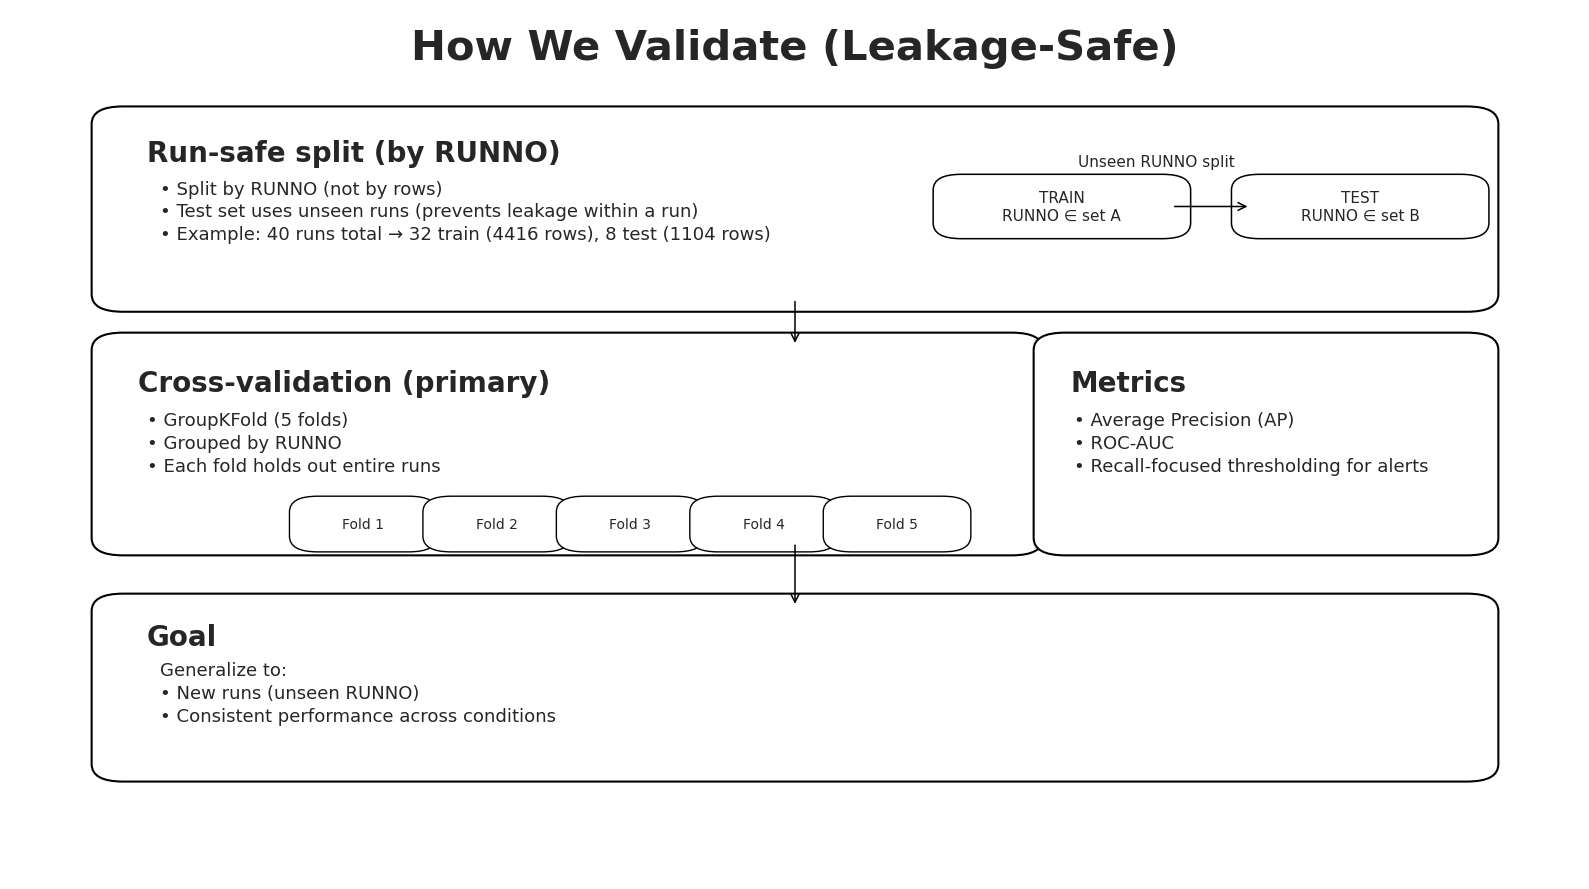

✅ Saved diagram to: slide10_validation_diagram_v5.png


In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TOTAL_RUNS = 40
TRAIN_RUNS = 32
TEST_RUNS  = 8
TRAIN_ROWS = 4416
TEST_ROWS  = 1104
N_FOLDS    = 5
GROUP_COL  = "RUNNO"

out_path = "slide10_validation_diagram_v5.png"

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def card(x, y, w, h, title, body_lines=None, title_fs=20, body_fs=13, lw=1.5):
    p = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.018,rounding_size=0.02",
        linewidth=lw, facecolor="white", edgecolor="black"
    )
    ax.add_patch(p)
    ax.text(x + 0.02*w, y + h - 0.18*h, title, fontsize=title_fs, fontweight="bold", va="center")
    if body_lines:
        ax.text(
            x + 0.03*w, y + h - 0.33*h,
            "\n".join(body_lines),
            fontsize=body_fs, va="top", linespacing=1.35
        )
    return p

def small_box(x, y, w, h, text, fs=11, lw=1.1):
    p = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.018",
        linewidth=lw, facecolor="white", edgecolor="black"
    )
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)
    return p

def arrow(x1, y1, x2, y2, lw=1.1):
    a = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=14,
        linewidth=lw, color="black"
    )
    ax.add_patch(a)

# Title
ax.text(0.5, 0.955, "How We Validate (Leakage-Safe)", ha="center", va="center",
        fontsize=30, fontweight="bold")

# Layout
left, width = 0.07, 0.86
top_y, mid_y, goal_y = 0.67, 0.39, 0.13

# Top card
card(left, top_y, width, 0.20,
     f"Run-safe split (by {GROUP_COL})",
     body_lines=[
         f"• Split by {GROUP_COL} (not by rows)",
         f"• Test set uses unseen runs (prevents leakage within a run)",
         f"• Example: {TOTAL_RUNS} runs total → {TRAIN_RUNS} train ({TRAIN_ROWS} rows), {TEST_RUNS} test ({TEST_ROWS} rows)"
     ])

# Mini diagram moved LEFT and slightly smaller so it stays inside border
mini_label_x = 0.73
mini_label_y = top_y + 0.155
ax.text(mini_label_x, mini_label_y, "Unseen RUNNO split", ha="center", va="center", fontsize=11)

train_x, train_y, bw, bh = 0.60, top_y + 0.078, 0.14, 0.050
test_x  = 0.79  # pulled left so it doesn't touch/right-overflow
small_box(train_x, train_y, bw, bh, "TRAIN\nRUNNO ∈ set A", fs=11)
small_box(test_x,  train_y, bw, bh, "TEST\nRUNNO ∈ set B", fs=11)

# Shorter arrow between boxes
arrow(train_x + bw, train_y + bh/2, test_x, train_y + bh/2, lw=1.1)

# Middle cards
card(left, mid_y, 0.57, 0.22,
     "Cross-validation (primary)",
     body_lines=[
         f"• GroupKFold ({N_FOLDS} folds)",
         f"• Grouped by {GROUP_COL}",
         f"• Each fold holds out entire runs"
     ])

card(left + 0.60, mid_y, 0.26, 0.22,
     "Metrics",
     body_lines=[
         "• Average Precision (AP)",
         "• ROC-AUC",
         "• Recall-focused thresholding for alerts"
     ])

# Fold boxes lowered a bit more
fold_y = mid_y - 0.002
fold_x0, fold_w, fold_h, gap = left + 0.12, 0.070, 0.040, 0.015
for i in range(N_FOLDS):
    small_box(fold_x0 + i*(fold_w + gap), fold_y, fold_w, fold_h, f"Fold {i+1}", fs=10, lw=1.0)

# Goal card
card(left, goal_y, width, 0.18,
     "Goal",
     body_lines=[
         "Generalize to:",
         f"• New runs (unseen {GROUP_COL})",
         "• Consistent performance across conditions"
     ])

# Arrows between sections (short + light)
arrow(0.50, top_y - 0.003, 0.50, mid_y + 0.22 + 0.003, lw=1.1)
arrow(0.50, mid_y - 0.003, 0.50, goal_y + 0.18 + 0.003, lw=1.1)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved diagram to: {out_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/box1_run_safe_cv_performance.png'

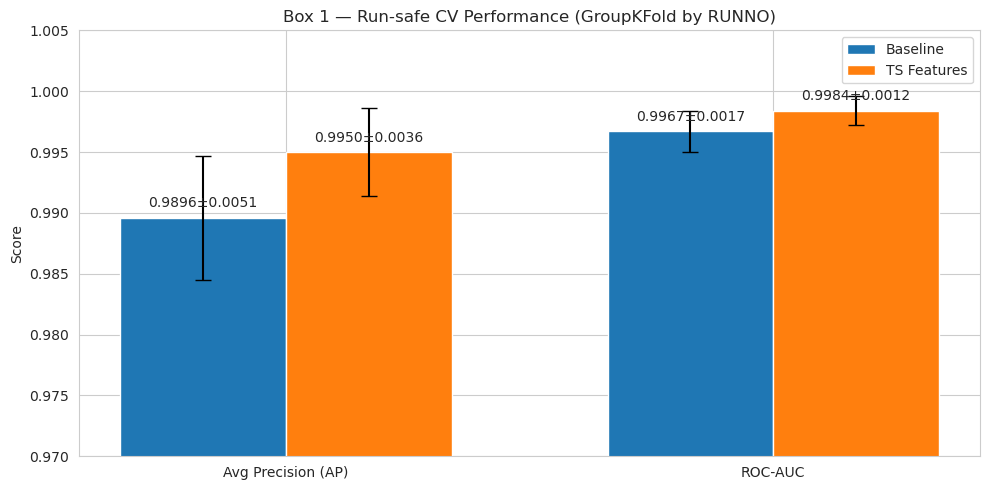

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Numbers from your summary (GroupKFold by RUNNO, mean ± std)
models = ["Baseline", "TS Features"]
metrics = ["Avg Precision (AP)", "ROC-AUC"]

means = np.array([
    [0.9896, 0.9967],  # Baseline
    [0.9950, 0.9984],  # TS Features
])
stds = np.array([
    [0.0051, 0.0017],
    [0.0036, 0.0012],
])

x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, means[0], width, yerr=stds[0], capsize=6, label=models[0])
ax.bar(x + width/2, means[1], width, yerr=stds[1], capsize=6, label=models[1])

ax.set_title("Box 1 — Run-safe CV Performance (GroupKFold by RUNNO)")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.97, 1.005)  # zoomed to show differences clearly
ax.legend()

# Add value labels
for i in range(means.shape[0]):
    for j in range(means.shape[1]):
        xpos = x[j] + (-width/2 if i == 0 else width/2)
        ax.text(
            xpos,
            means[i, j] + 0.0006,
            f"{means[i, j]:.4f}±{stds[i, j]:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()

out_path = "/mnt/data/box1_run_safe_cv_performance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

out_path

Total=5,520 | Positive(1)=1,612 (29.20%) | Negative(0)=3,908 (70.80%)


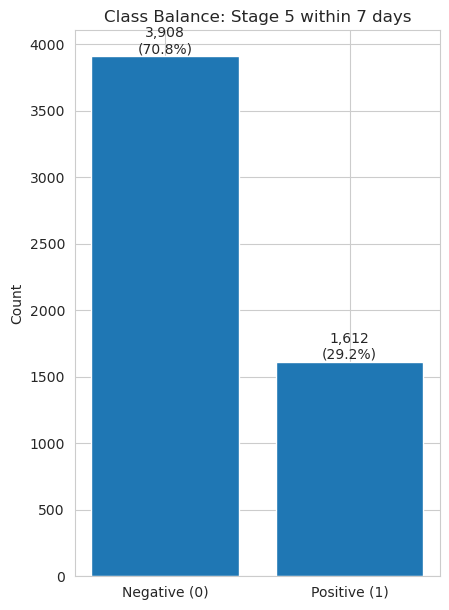

Saved: class_balance_stage5_within_7d.png


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Assumes you already have df loaded with at least: RUNNO, GSTD, DOY and/or WDATE, TRTNO/TRTNA ----
# If your df name is different, change df below.

# 1) Choose grouping + time columns that exist in your dataset
group_cols = [c for c in ["RUNNO", "TRTNO"] if c in df.columns]
if not group_cols:
    raise ValueError("Could not find RUNNO/TRTNO columns for grouping.")

# Prefer DOY for ordering; if not available, use WDATE
time_col = "DOY" if "DOY" in df.columns else ("WDATE" if "WDATE" in df.columns else None)
if time_col is None:
    raise ValueError("Could not find DOY or WDATE for time ordering.")

# 2) Build (or reuse) the binary early-warning label:
# y_t = 1 if GSTD==5 occurs in the next 7 days (t+1..t+7), else 0
label_col = "stage5_within_7d"

if label_col not in df.columns:
    df_sorted = df.sort_values(group_cols + [time_col]).copy()

    def stage5_within_7d(g):
        is5 = (g["GSTD"] == 5).astype(int)

        # future 7 days excluding today:
        # reverse -> rolling max -> shift(1) to exclude current day -> reverse back
        future7 = (
            is5.iloc[::-1]
              .rolling(window=7, min_periods=1)
              .max()
              .shift(1)
              .fillna(0)
              .iloc[::-1]
              .astype(int)
        )
        return future7

    df_sorted[label_col] = df_sorted.groupby(group_cols, group_keys=False).apply(stage5_within_7d)

    # merge back to original df order (by index)
    df[label_col] = df_sorted[label_col].reindex(df.index)

# 3) Class balance counts + %
counts = df[label_col].value_counts(dropna=False).sort_index()
neg = int(counts.get(0, 0))
pos = int(counts.get(1, 0))
total = neg + pos

pos_pct = (pos / total * 100) if total else 0
neg_pct = (neg / total * 100) if total else 0

print(f"Total={total:,} | Positive(1)={pos:,} ({pos_pct:.2f}%) | Negative(0)={neg:,} ({neg_pct:.2f}%)")

# 4) Plot: simple bar chart (portrait-friendly) and save
fig, ax = plt.subplots(figsize=(4.6, 6.2))  # portrait
ax.bar(["Negative (0)", "Positive (1)"], [neg, pos])

ax.set_title("Class Balance: Stage 5 within 7 days")
ax.set_ylabel("Count")

# Add labels on top of bars
ax.text(0, neg, f"{neg:,}\n({neg_pct:.1f}%)", ha="center", va="bottom")
ax.text(1, pos, f"{pos:,}\n({pos_pct:.1f}%)", ha="center", va="bottom")

plt.tight_layout()

out_path = "class_balance_stage5_within_7d.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)